# EDIS 8100 · Week 4 · Mini Project 1

## Building a teacher dashboard on real student records, and reading it critically

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

Today we build three panels of a teacher-facing dashboard for a module team with one week of outreach time and 2,237 students. Then we spend at least as long on the second half: what each panel would lead a teacher to do, and where it would mislead them.

We work through this notebook in the first block of class, 3:30 to 4:20, and return to it in the debrief, 5:30 to 5:50. Our guest, Yeonji Jung of Texas A&M University, holds 4:30 to 5:30.

Every cell already contains working code, and there is no expectation that you write code from scratch in this course. Your attention is better spent on what the output might mean. Questions are welcome at any point, including questions about a single line.

### What is assessed

This notebook is Mini Project 1, and it is submitted. Coding skill is not what is assessed. The design memo in Part F is the primary component used for grading, with the critique table in Part E close behind it. A run with nothing edited still produces every finding the assignment is about.

### The records are real

The files come from the **Open University Learning Analytics Dataset**: 4,529 enrollments in one online module at the Open University in the United Kingdom, presentations starting October 2013 and October 2014. A research team anonymized the records and published them.

What matters this week is where the records end up. A result that stays inside a notebook is read by the person who produced it. Here every panel title, every legend, and every flag label is an interface a teacher acts on, at speed, without reading the code underneath.

The export also has irregularities that a teaching example usually removes: one column writes nine of its ten labels with a percent sign and one without, twenty-nine enrollments have no socioeconomic band, and 738 have no recorded click. Rather than dropping those rows without saying so, the notebook states a decision and reports what it affects.

### What I hope you leave with

1. A three-panel teacher-facing dashboard built from a real virtual learning environment export.
2. Being able to state the provenance of a dataset: who collected it, under what license, and what it may be used for.
3. A reason attached to every automated flag, and a look at how the resulting list falls across socioeconomic bands.
4. A sense of what a fairness statistic can and cannot support at a given caseload, and the habit of checking a model against the simplest rule that would have replaced it.
5. A reading of each panel against the decision a teacher would face, drawing on van Leeuwen, Teasley, and Wise (2022) and Wise and Jung (2019).
6. A 300-word design memo arguing for one specific design change and saying who it protects.


## How to work through this notebook

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**.
- **The first code cell downloads the data.** It needs an internet connection and installs nothing on your machine. If anything goes wrong later, `Runtime > Restart session and run all` in Colab, or `Kernel > Restart & Run All` in Jupyter, resolves almost everything.
- Cells marked **Your turn** already hold a working value, so the notebook runs start to finish without any editing. Changing a value and re-running shows what that choice was doing.
- **Each interactive plotly chart is followed by a plain snapshot of the same panel**, because plotly does not render when a notebook is read on GitHub.
- **If you have not written code before,** read the code the way you read a methods section: you are checking what was done to the data, not memorizing syntax. When a line does not make sense, please ask.

### The route for today

| | Sections |
|---|---|
| **CORE, about 55 to 60 minutes** | Provenance and setup; Part A, the decision log and Your turn 1; Part B, the class overview panel and its discussion; Part C, the model card, the panel, and its discussion |
| **IF TIME** | Your turn 2, the caseload and the roster rule; Part D, the drilldown, with Your turn 3; the vocabulary the critique and the memo use |
| **EXPLORE LATER, after class and before the September 20 deadline** | Part E, the critique printout and Your turn 4; Part F, the design memo; Part G, rebuilding the dashboard with an AI tool; the optional student-facing section; the two appendices |

Parts E and F are the graded core of Mini Project 1 and are completed after class. Part G, the optional section, and the appendices sit outside the class session.


## Where this data comes from

**Dataset.** The Open University Learning Analytics Dataset (OULAD), module **BBB**, presentations **2013J** and **2014J**. A "presentation" is one run of a module, so 2013J is the October 2013 cohort and 2014J is the October 2014 cohort of the same course.

**Who collected it and why.** The Open University is a large distance-teaching university in the United Kingdom. Its Knowledge Media Institute assembled routine administrative and virtual learning environment records for seven modules, removed names and direct identifiers, coarsened the demographic fields into bands, and released the result in 2017 so that the data could be used in research outside the university (Kuzilek, Hlosta, and Zdrahal, 2017).

**License.** Creative Commons Attribution 4.0 (CC BY 4.0). You may use, share, and adapt it, including commercially, as long as you credit the source.

**Citation.** Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171.

**The people in the file.** These records describe students at a distance-learning university that requires no previous qualifications for entry. Kuzilek, Hlosta, and Zdrahal (2017) report that students are informed at admission that their data are used for academic research and may be shared with other researchers, that the Open University offers no opt-out from learning analytics research, and that the released file was anonymized with the demographic fields banded.

The course subset used here lives in a small public repository so that it loads in one line:

`https://github.com/HakeoungLee/edis8100-datasets`

**Run the cell below.** It fetches six files and reports what arrived.


In [1]:
%matplotlib inline
# the line above just tells the notebook to draw matplotlib charts here on the page

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Plotly has to know where it is drawing. Inside Colab it uses Colab's own renderer;
# anywhere else (local Jupyter, nbconvert) it uses the standard notebook renderer.
pio.renderers.default = "colab" if "google.colab" in sys.modules else "notebook_connected"

pd.set_option("display.width", 140)

# A colorblind-safe palette (Okabe and Ito). Nothing in this notebook asks you to
# tell red from green, and every color distinction is backed up by a shape or a label.
BLUE, ORANGE, SKY, PURPLE, GREY, VERM, GREEN = (
    "#0072b2", "#e69f00", "#56b4e9", "#cc79a7", "#7f7f7f", "#d55e00", "#009e73")

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main"

TABLES = {
    "student_info":       ("studentInfo.csv",        "one enrollment: who registered, and how it ended"),
    "student_vle":        ("studentVle.csv.gz",      "one student, one resource, one day: how many clicks"),
    "student_assessment": ("studentAssessment.csv",  "one submitted assessment"),
    "assessments":        ("assessments.csv",        "one assessment: its type, due day, and weight"),
    "registration":       ("studentRegistration.csv","one enrollment: when they signed up, when they left"),
    "vle":                ("vle.csv",                "one resource in the virtual learning environment"),
}

try:
    raw = {key: pd.read_csv(f"{BASE}/oulad-bbb/{fname}") for key, (fname, _) in TABLES.items()}
except Exception as err:
    print("=" * 78)
    print("  The download did not work, so nothing below this cell will run yet.")
    print("=" * 78)
    print("  This notebook reads six files from the course dataset repository:")
    print("      https://github.com/HakeoungLee/edis8100-datasets")
    print("  under the folder  oulad-bbb/ .")
    print()
    print("  Three things to try, in order:")
    print("    1. Check that this runtime has internet. In Colab it always does;")
    print("       on a locked-down campus network it sometimes does not.")
    print("    2. Run this cell again. Short network hiccups are common.")
    print("    3. If it still fails, download the six CSV files from the repository")
    print("       by hand, put them beside this notebook, and change BASE above to")
    print('       BASE = "."  so that pandas reads them from disk instead.')
    print()
    print(f"  The underlying message, for your instructor: {type(err).__name__}: {err}")
    print("=" * 78)
    raise SystemExit("Could not download the course datasets. Read the message above.")

student_info       = raw["student_info"]
student_vle        = raw["student_vle"]
student_assessment = raw["student_assessment"]
assessments        = raw["assessments"]
registration       = raw["registration"]
vle_resources      = raw["vle"]

print("=" * 78)
print("  Open University Learning Analytics Dataset, module BBB, 2013J and 2014J")
print("  Kuzilek, Hlosta, and Zdrahal (2017), Scientific Data 4:170171 · CC BY 4.0")
print("=" * 78)
for key, (fname, grain) in TABLES.items():
    df = raw[key]
    print(f"  {fname:<24} {len(df):>9,} rows x {df.shape[1]:>2}   {grain}")
print("=" * 78)
print(f"  {len(student_info):,} enrollments in two runs of one module:")
for pres, n in student_info["code_presentation"].value_counts().sort_index().items():
    print(f"      {pres}   {n:>6,} students")
print("  Everything arrived. Nothing was installed, and nothing was written to disk.")
print("=" * 78)

  Open University Learning Analytics Dataset, module BBB, 2013J and 2014J
  Kuzilek, Hlosta, and Zdrahal (2017), Scientific Data 4:170171 · CC BY 4.0
  studentInfo.csv              4,529 rows x 12   one enrollment: who registered, and how it ended
  studentVle.csv.gz          891,062 rows x  6   one student, one resource, one day: how many clicks
  studentAssessment.csv       21,783 rows x  5   one submitted assessment
  assessments.csv                 18 rows x  6   one assessment: its type, due day, and weight
  studentRegistration.csv      4,529 rows x  5   one enrollment: when they signed up, when they left
  vle.csv                        528 rows x  6   one resource in the virtual learning environment
  4,529 enrollments in two runs of one module:
      2013J    2,237 students
      2014J    2,292 students
  Everything arrived. Nothing was installed, and nothing was written to disk.


## Part A. Orientation

Before anyone draws a chart, the useful question is what the files can and cannot say. A dashboard inherits every limit of the data underneath it, and a clean layout makes those limits difficult to see. That is one common way a dashboard misleads: it looks complete.

**Run the cell below.** It builds the one table every panel needs, **one row per enrollment**, and prints a decision log while it does it. Each entry in that log is an irregularity in the export where somebody had to choose.

Six decisions are coming, and three of them return in Part E:

1. `imd_band` spells nine of its ten categories with a percent sign and one without.
2. Twenty-nine enrollments have no `imd_band` at all.
3. Some enrollments have recorded clicks before day 0, the presentation's official start, so day numbers in this file can be negative. Kuzilek, Hlosta, and Zdrahal (2017) note that module content is usually available a couple of weeks before the start.
4. Hundreds of enrollments have no rows in the clickstream whatsoever.
5. More than a thousand have no recorded submission for the first assignment, so their score is not low, it is absent.
6. Hundreds unregistered from the module before day 1, and they are still sitting in the enrollment table.


In [2]:
# =========================================================================
# Build one row per enrollment. Everything the dashboard shows comes from here.
# =========================================================================
EARLY_WINDOW = 30      # "early warning" means the first 30 days of the module
FOCAL_TERM   = "2013J" # the presentation this dashboard is for
log = []               # the decision log, printed at the bottom of this cell


def say(label, text, width=70, pad=18):
    """Print one labelled line of the decision log, wrapped so it stays readable."""
    words, line, out = text.split(), "", []
    for w in words:
        if len(line) + len(w) + 1 > width:
            out.append(line); line = w
        else:
            line = f"{line} {w}".strip()
    out.append(line)
    print(f"     {label:<{pad}}{out[0]}")
    for extra in out[1:]:
        print(f"     {'':<{pad}}{extra}")

# ---- decision 1: one imd_band label is spelled differently from the rest ----
imd_labels_raw = sorted(student_info["imd_band"].dropna().unique())
IMD_ORDER = ["0-10", "10-20", "20-30", "30-40", "40-50",
             "50-60", "60-70", "70-80", "80-90", "90-100"]
si = student_info.copy()
si["imd_clean"] = si["imd_band"].str.replace("%", "", regex=False)
si["imd_decile"] = si["imd_clean"].map({v: i + 1 for i, v in enumerate(IMD_ORDER)})
log.append(("1. ONE COLUMN SPELLS ITSELF TWO WAYS",
            f"nine of the ten deprivation bands are written with a percent sign, "
            f"and {imd_labels_raw[1]!r} is not",
            "strip the sign and map all ten to deciles 1 to 10",
            "nothing here, but grouping on the raw column would have split one "
            "decile into two categories without saying so"))

# ---- decision 2: 29 enrollments have no imd_band at all ---------------------
n_imd_missing = int(si["imd_decile"].isna().sum())
si["imd_group"] = np.where(si["imd_decile"] <= 3, "Most deprived 30%",
                    np.where(si["imd_decile"].isna(), "Not recorded", "Rest of the class"))
log.append(("2. SOME ENROLLMENTS HAVE NO DEPRIVATION BAND",
            f"{n_imd_missing} of {len(si):,} enrollments have that field left blank",
            'keep them in a visible "Not recorded" group instead of dropping them',
            "the flag-rate comparison later leaves them out, because you cannot audit "
            "a group you cannot name. The share of the class and the share of the list "
            "still count them. Dropping them would have hidden both of those facts."))

# ---- decision 3: the clickstream starts before the module does --------------
n_pre = int((student_vle["date"] < 0).sum())
n_pre_students = int(student_vle.loc[student_vle["date"] < 0, "id_student"].nunique())
early_rows = student_vle[(student_vle["date"] >= 0) & (student_vle["date"] < EARLY_WINDOW)]
log.append(("3. DAY NUMBERS CAN BE NEGATIVE",
            f"{n_pre:,} click rows from {n_pre_students:,} students are dated before day 0, "
            f"the module's official start",
            f"count only days 0 to {EARLY_WINDOW - 1} as the early window",
            "an enrollment with two weeks of recorded clicks before the start and one "
            "with none look identical in that window"))

early = (early_rows.groupby(["code_presentation", "id_student"])
         .agg(clicks_first30=("sum_click", "sum"),
              active_days_first30=("date", "nunique")).reset_index())
whole_term = (student_vle.groupby(["code_presentation", "id_student"])
              .agg(clicks_total=("sum_click", "sum"),
                   last_click_day=("date", "max")).reset_index())

# ---- the first tutor-marked assignment of each presentation -----------------
tma = assessments[assessments["assessment_type"] == "TMA"].sort_values("date")
first_tma = tma.groupby("code_presentation").first().reset_index()
tma1_ids = dict(zip(first_tma["code_presentation"], first_tma["id_assessment"]))
tma1_day = dict(zip(first_tma["code_presentation"], first_tma["date"]))

subs = student_assessment.merge(assessments, on="id_assessment")
# Kuzilek, Hlosta, and Zdrahal (2017) define is_banked as a result transferred
# from a previous presentation. A banked result was not produced in this
# presentation, so counting it as this term's assignment 1 would hand the model a
# feature built on an earlier run of the module. Those rows are set aside here for
# that reason. The audit prints below.
tma1_all = subs[subs["id_assessment"].isin(tma1_ids.values())]
banked = tma1_all[tma1_all["is_banked"] == 1]
n_banked = int(len(banked))
tma1 = (tma1_all[tma1_all["is_banked"] == 0]
        [["code_presentation", "id_student", "score", "date_submitted"]]
        .rename(columns={"score": "tma1_score", "date_submitted": "tma1_day"}))

# ---- assemble ---------------------------------------------------------------
dash = (si
        .merge(early,      on=["code_presentation", "id_student"], how="left")
        .merge(whole_term, on=["code_presentation", "id_student"], how="left")
        .merge(tma1,       on=["code_presentation", "id_student"], how="left")
        .merge(registration[["code_presentation", "id_student",
                             "date_registration", "date_unregistration"]],
               on=["code_presentation", "id_student"], how="left"))

# ---- decision 4: enrollments with no clickstream rows at all ----------------
n_no_clicks = int(dash["clicks_total"].isna().sum())
n_no_early  = int(dash["clicks_first30"].isna().sum())
dash["ever_active"] = dash["clicks_total"].notna().astype(int)
for col in ["clicks_first30", "active_days_first30", "clicks_total"]:
    dash[col] = dash[col].fillna(0).astype(int)
log.append(("4. HUNDREDS OF ENROLLMENTS HAVE NO CLICKS AT ALL",
            f"{n_no_clicks} of {len(dash):,} enrollments appear nowhere in the clickstream",
            "fill their counts with 0 and keep a separate marker saying they were never seen",
            "a 0 in this table is a measurement and an absence is not. A missing row "
            "can mean the person did not act, or that the action was not logged. "
            "This file cannot tell you which."))

# ---- decision 5: not submitting is not the same as scoring zero ------------
n_no_tma1 = int(dash["tma1_score"].isna().sum())
dash["tma1_submitted"] = dash["tma1_score"].notna().astype(int)
dash["tma1_score_filled"] = dash["tma1_score"].fillna(0.0)
log.append(("5. NOT SUBMITTING IS RECORDED AS NOTHING, NOT AS ZERO",
            f"{n_no_tma1:,} enrollments have no score for the first assignment in this "
            "presentation",
            "fill the score with 0 and add a separate yes-or-no column saying whether a "
            "score exists at all, so that a real zero and a missing submission are not "
            "the same input. Filling with the median is the other common choice",
            "that column says a score is missing and never says why. Somebody ill in "
            "week 3, somebody who decided the module was not for them, and somebody "
            f"whose upload failed are one input. A further {n_banked} results were carried "
            "over from an earlier run of the module; they are set aside and count as no "
            "submission here."))

# ---- an audit the next decision is built on --------------------------------
# Kuzilek et al. state that students who unregister have Withdrawn as their
# final_result. Decision 6, the still-registered rule in Part C, and Part E item 5
# all build on that, so it is checked here rather than assumed.
_has_date = dash["date_unregistration"].notna()
_dated = dash.loc[_has_date, "final_result"].value_counts()
_undated_withdrawn = int((~_has_date & (dash["final_result"] == "Withdrawn")).sum())
print("=" * 78)
print("  TWO CHECKS BEFORE THE DECISIONS")
print("=" * 78)
print("\n  Does an unregistration date always mean the enrollment ended Withdrawn?")
print(f"    Almost. {int(_has_date.sum()):,} enrollments carry a date: "
      f"{int(_dated.get('Withdrawn', 0)):,} ended Withdrawn and "
      f"{int(_dated.get('Fail', 0))} ended Fail.")
print(f"    Another {_undated_withdrawn} ended Withdrawn with no date recorded at all.")
print("    So the date and the result are two separate records. The notebook reads")
print("    them separately rather than treating one as a stand-in for the other.")
print(f"\n  Are the {n_banked} banked assignment-1 results really from an earlier run?")
print(f"    Yes. All {n_banked} are in "
      f"{', '.join(sorted(banked['code_presentation'].unique()))}, and every one carries a "
      f"submission")
print(f"    day of {int(banked['date_submitted'].max())}, which is how this file marks a "
      "result carried over from")
print("    a previous run of the module.")
print("    Those enrollments ended:")
_bk = dash.merge(banked[["code_presentation", "id_student"]], on=["code_presentation", "id_student"])
print("      " + ",  ".join(f"{k} {v}" for k, v in _bk["final_result"].value_counts().items()))
print(f"    {int((_bk['clicks_first30'] == 0).sum())} of them have no recorded click in days "
      f"0 to {EARLY_WINDOW - 1}.")
print("    Set aside, so they count as no submission this term.")

# ---- decision 6: enrollments with an unregistration date on or before day 0 --
gone_before_start = dash["date_unregistration"].notna() & (dash["date_unregistration"] <= 0)
dash["left_before_day_1"] = gone_before_start.astype(int)
n_gone = int(gone_before_start.sum())
n_gone_silent = int((dash.loc[gone_before_start, "clicks_total"] == 0).sum())
log.append(("6. HUNDREDS UNREGISTERED BEFORE DAY 1 AND STAYED IN THE ROSTER",
            f"{n_gone} enrollments have an unregistration date on or before day 0, and "
            f"{n_gone_silent} of those never clicked anywhere",
            "keep them, for now",
            "a university ships the dashboard on the enrollment table it has. Part E "
            "reports what keeping them does to the flag list."))

# ---- the outcome the dashboard cares about ---------------------------------
# The naming rule matters more on a dashboard than in a notebook: did_not_pass
# describes what a registry recorded about an enrollment.
# "At risk" would describe a person, in the present tense, on a teacher's screen.
dash["completed"]     = dash["final_result"].isin(["Pass", "Distinction"]).astype(int)
dash["did_not_pass"]  = dash["final_result"].isin(["Fail", "Withdrawn"]).astype(int)

# ---- print the log ----------------------------------------------------------
print("\n" + "=" * 78)
print("  THE DECISION LOG")
print("  Six places where the export is ragged and somebody had to choose.")
print("=" * 78)
for title, in_file, we_did, cost in log:
    print(f"\n  {title}")
    say("The file says", in_file)
    say("So we", we_did)
    say("It costs", cost)

print("\n" + "=" * 78)
print("  THE TABLE THE DASHBOARD IS BUILT ON")
print(f"  {dash.shape[0]:,} enrollments, one row each, {dash.shape[1]} columns")
print("=" * 78)
print("\n  How the registry closed each enrollment:\n")
counts = dash["final_result"].value_counts()
for label in ["Distinction", "Pass", "Fail", "Withdrawn"]:
    print(f"      {label:<12} {counts[label]:>6,}   ({counts[label] / len(dash):>5.1%})")
print(f"\n  Fail and Withdrawn are treated together, as the one outcome the dashboard")
print(f"  cares about: {dash['did_not_pass'].sum():,} of {len(dash):,}, or "
      f"{dash['did_not_pass'].mean():.1%} of all enrollments.")
print("\n  That is a seventh decision. It says an enrollment that records a Fail and an")
print("  enrollment that records somebody leaving in week 3 are the same kind of case.")
print("  They are not. We do it because a teacher's outreach list does not distinguish")
print("  them either, and Part E comes back to it.")
print("=" * 78)

  TWO CHECKS BEFORE THE DECISIONS

  Does an unregistration date always mean the enrollment ended Withdrawn?
    Almost. 1,383 enrollments carry a date: 1,380 ended Withdrawn and 3 ended Fail.
    Another 13 ended Withdrawn with no date recorded at all.
    So the date and the result are two separate records. The notebook reads
    them separately rather than treating one as a stand-in for the other.

  Are the 50 banked assignment-1 results really from an earlier run?
    Yes. All 50 are in 2013J, and every one carries a submission
    day of -1, which is how this file marks a result carried over from
    a previous run of the module.
    Those enrollments ended:
      Fail 24,  Pass 13,  Withdrawn 12,  Distinction 1
    20 of them have no recorded click in days 0 to 29.
    Set aside, so they count as no submission this term.

  THE DECISION LOG
  Six places where the export is ragged and somebody had to choose.

  1. ONE COLUMN SPELLS ITSELF TWO WAYS
     The file says     nine of t

**Let's look at the output.** Three entries in that log.

**More than half of these enrollments end in Fail or Withdrawn.** The Open University requires no previous qualifications for entry (Kuzilek, Hlosta, and Zdrahal, 2017). Every rate computed below sits on top of that base rate, and a model that flags nobody at all is already right about half the time.

**Zero is not the same as missing, and this file cannot tell which one you have.** 738 enrollments have no clickstream rows at all. The log records a click, not a person, and a "0" on a dashboard reads as a fact about somebody rather than as a gap in an instrument.

**576 enrollments carry an unregistration date on or before day 0**, across the two presentations.

| | |
|---|---|
| **What the data directly show** | 738 of 4,529 enrollments have no row anywhere in the clickstream; of the 576 enrollments carrying an unregistration date on or before day 0, 496 have no click recorded anywhere |
| **A plausible interpretation** | Some of those enrollments belong to people who registered, never opened the site, and withdrew |
| **What these files cannot establish** | Which ones. A missing row can mean that somebody did not act or that the activity was not logged, and somebody studying from downloaded material would appear the same way |

*Connecting to the readings.* van Leeuwen, Teasley, and Wise (2022) organize the design space for teacher-facing and student-facing analytics partly by what the displayed information represents and what response the display presumes of whoever receives it. A count of zero clicks is a good place to ask both questions at once: what is it a representation of, and what does putting it on a screen presume the teacher will do?


### Your turn 1: two questions

Before anything gets built, please write down one question these files **could** genuinely inform, and one they **cannot touch** no matter how good the charts are.

The cell below already contains a working pair of answers, so the notebook runs untouched. You might replace them with your own. Concrete tends to work better than sweeping: "is this student motivated" is not a question the files can answer, and it is also not specific enough to be interesting.

Your answers print into a design brief that Part E, the memo, and Part G all use.


In [3]:
# TODO: replace these two strings with your own questions.
#          The defaults below already work, so you can run this cell first and edit after.

QUESTION_THE_FILES_CAN_INFORM = (
    "Which students who submitted the first assignment stopped clicking entirely "
    "before the third one was due?"
)

QUESTION_THE_FILES_CANNOT_TOUCH = (
    "Of the students who left, which ones left because the module was wrong for them "
    "and which left because their circumstances changed?"
)


# --- a friendly safety net: blank answers fall back to the defaults ---------
_a = QUESTION_THE_FILES_CAN_INFORM.strip() or "Who stopped clicking after the first assignment?"
_b = QUESTION_THE_FILES_CANNOT_TOUCH.strip() or "Why did they stop?"

def wrap(text, width=74, indent="  "):
    words, line, out = text.split(), "", []
    for w in words:
        if len(line) + len(w) + 1 > width:
            out.append(indent + line); line = w
        else:
            line = f"{line} {w}".strip()
    out.append(indent + line)
    return "\n".join(out)

print("=" * 78)
print("  DESIGN BRIEF: MINI PROJECT 1")
print("=" * 78)
print("\n  A question these files CAN inform:\n")
print(wrap(_a))
print("\n  A question these files CANNOT touch:\n")
print(wrap(_b))
print("\n" + "=" * 78)
print("  Keep the second question visible while you build. Every panel below is")
print("  built from the first kind of question, and a teacher reading the screen")
print("  has no way to tell the difference.")
print("=" * 78)

  DESIGN BRIEF: MINI PROJECT 1

  A question these files CAN inform:

  Which students who submitted the first assignment stopped clicking
  entirely before the third one was due?

  A question these files CANNOT touch:

  Of the students who left, which ones left because the module was wrong for
  them and which left because their circumstances changed?

  Keep the second question visible while you build. Every panel below is
  built from the first kind of question, and a teacher reading the screen
  has no way to tell the difference.


## Part B. The class overview panel

This is the panel a teacher sees first, usually at the start of a week. It has to answer "how is my module doing" quickly.

The archive holds two runs. BBB ran twice: **2013J** with 2,237 students and **2014J** with 2,292, same module, one year apart. The two enrollment tables share 47 student ids, and the cell below counts them. So the panel can address a question many instructors ask and few dashboards support:

> Is what I am looking at a property of my course, or a property of this particular group of people?

Answering it means looking at another run. A teacher in the middle of a term does not have one. The archive does, so every chart below is drawn twice, once per presentation.

### The four charts

1. **How each run ended.** The four outcomes as shares. Withdrawal is shown separately from failure, because they are different events with different remedies.
2. **When the module was worked.** Recorded clicks per enrolled student by week across the term, with the tutor-marked assignment weeks marked.
3. **Does recorded early activity go with finishing?** Completion rate by fifth of first-30-day clicks. If the two lines lie close together, the 2013J pattern recurred in 2014J.
4. **Completion by deprivation decile.** The same chart, with the class split by the UK Index of Multiple Deprivation of the area each student lived in. Decile 1 is the most deprived tenth of neighborhoods.

### Before chart 4: what that variable records

The `imd_band` column is the Index of Multiple Deprivation band of the place where the student lived during the module presentation (Kuzilek, Hlosta, and Zdrahal, 2017). The index is an **area-level** measure. It is not a measurement of the student, of their household, or of anything they did, and reading an area score as a property of the people who live there is an error.

The decile groups here hold between 126 and 302 enrollments, so each point carries real uncertainty, which is what every interval on the chart is there to make visible.

**Run the cell below.** It computes the inputs for all four charts and prints the numbers behind them.


In [4]:
# =========================================================================
# Inputs for the four class-overview charts. Everything is aggregated BEFORE
# it is plotted, so no chart ships 2,237 individual points to your browser.
# =========================================================================
PRESENTATIONS = ["2013J", "2014J"]
PRES_COLOR = {"2013J": BLUE, "2014J": ORANGE}
OUTCOMES = ["Distinction", "Pass", "Fail", "Withdrawn"]
OUTCOME_COLOR = {"Distinction": BLUE, "Pass": SKY, "Fail": ORANGE, "Withdrawn": GREY}

# ---- 1. how each run ended --------------------------------------------------
outcome_share = (dash.pivot_table(index="code_presentation", columns="final_result",
                                  values="id_student", aggfunc="size")
                 .reindex(columns=OUTCOMES).fillna(0))
outcome_share = outcome_share.div(outcome_share.sum(axis=1), axis=0)

# ---- 2. clicks per student per week ----------------------------------------
clicks_wk = student_vle.copy()
clicks_wk["week"] = np.floor(clicks_wk["date"] / 7).astype(int)
clicks_wk = clicks_wk[clicks_wk["week"] >= 0]
weekly = (clicks_wk.pivot_table(index="week", columns="code_presentation",
                                values="sum_click", aggfunc="sum"))
enrolled = dash["code_presentation"].value_counts()
weekly_per_student = weekly.div(enrolled, axis=1)          # comparable across cohorts
tma_weeks = {p: sorted((assessments.loc[(assessments["code_presentation"] == p) &
                                        (assessments["assessment_type"] == "TMA"),
                                        "date"] // 7).astype(int).tolist())
             for p in PRESENTATIONS}

# ---- 3. completion by fifth of early activity -------------------------------
fifths = []
for pres in PRESENTATIONS:
    g = dash[dash["code_presentation"] == pres].copy()
    g["fifth"] = pd.qcut(g["clicks_first30"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
    fifths.append(g.groupby("fifth", observed=True)
                  .agg(students=("id_student", "size"),
                       median_clicks=("clicks_first30", "median"),
                       completion=("completed", "mean"))
                  .assign(code_presentation=pres).reset_index())
fifths = pd.concat(fifths, ignore_index=True)

# ---- 4. completion by deprivation decile ------------------------------------
by_imd = (dash.dropna(subset=["imd_decile"])
          .groupby(["code_presentation", "imd_decile"])
          .agg(students=("id_student", "size"), completion=("completed", "mean"))
          .reset_index())


def wilson(k, n, z=1.96):
    """95% interval for a proportion. Wilson, because normal intervals misbehave
    near 0 and 1 and several of these cells are small."""
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z ** 2 / n
    center = p + z ** 2 / (2 * n)
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2))
    return (center - half) / denom, (center + half) / denom


for frame in (fifths, by_imd):
    lo_hi = [wilson(round(c * s), s) for c, s in zip(frame["completion"], frame["students"])]
    frame["lo"] = [a for a, _ in lo_hi]
    frame["hi"] = [b for _, b in lo_hi]

# The gradient, rather than ten separate decile comparisons. A straight line through
# the ten decile rates, weighted by how many enrollments each decile holds, with a
# bootstrap interval resampling enrollments inside each decile.
grad_rng = np.random.default_rng(8100)
gradient = {}
for pres in PRESENTATIONS:
    g = dash[(dash["code_presentation"] == pres) & dash["imd_decile"].notna()]
    idx = {d: np.where((g["imd_decile"] == d).to_numpy())[0] for d in range(1, 11)}
    comp = g["completed"].to_numpy()
    w = np.sqrt([idx[d].size for d in range(1, 11)])
    point = np.polyfit(range(1, 11), [comp[idx[d]].mean() for d in range(1, 11)], 1, w=w)[0]
    draws = [np.polyfit(range(1, 11),
                        [comp[grad_rng.choice(idx[d], idx[d].size)].mean() for d in range(1, 11)],
                        1, w=w)[0] for _ in range(2000)]
    gap = comp[idx[10]].mean() - comp[idx[1]].mean()
    gap_lo, gap_hi = np.percentile(
        [comp[grad_rng.choice(idx[10], idx[10].size)].mean()
         - comp[grad_rng.choice(idx[1], idx[1].size)].mean() for _ in range(2000)], [2.5, 97.5])
    gradient[pres] = dict(slope=point, slope_lo=np.percentile(draws, 2.5),
                          slope_hi=np.percentile(draws, 97.5),
                          gap=gap, gap_lo=gap_lo, gap_hi=gap_hi,
                          n1=idx[1].size, n10=idx[10].size)

print("=" * 88)
print("  TWO RUNS OF THE SAME MODULE")
print("=" * 88)
head = f"  {'':<26}" + "".join(f"{p:>12}" for p in PRESENTATIONS)
print(head)
rows = [
    ("students enrolled",     lambda g: f"{len(g):,}"),
    ("completed (Pass/Dist)", lambda g: f"{g['completed'].mean():.1%}"),
    ("failed",                lambda g: f"{(g['final_result'] == 'Fail').mean():.1%}"),
    ("withdrew",              lambda g: f"{(g['final_result'] == 'Withdrawn').mean():.1%}"),
    ("median clicks, days 0-29", lambda g: f"{g['clicks_first30'].median():.0f}"),
    ("no clicks in days 0-29", lambda g: f"{(g['clicks_first30'] == 0).mean():.1%}"),
    ("submitted assignment 1", lambda g: f"{g['tma1_submitted'].mean():.1%}"),
    ("left before day 1",      lambda g: f"{g['left_before_day_1'].sum():,}"),
]
for label, fn in rows:
    line = f"  {label:<26}"
    for p in PRESENTATIONS:
        line += f"{fn(dash[dash['code_presentation'] == p]):>12}"
    print(line)
in_both = len(set(dash.loc[dash["code_presentation"] == "2013J", "id_student"]) &
              set(dash.loc[dash["code_presentation"] == "2014J", "id_student"]))
print(f"\n  {in_both} students appear in BOTH runs, so the two columns above are not")
print("  two separate groups of people. Those students are two enrollments, and every")
print("  table in this notebook counts them twice, because that is what the file is.")
print("=" * 88)
print("  Completion rate by fifth of first-30-day clicks, with 95% intervals:")
piv = fifths.pivot(index="fifth", columns="code_presentation", values="completion")
med = fifths.pivot(index="fifth", columns="code_presentation", values="median_clicks")
flo = fifths.pivot(index="fifth", columns="code_presentation", values="lo")
fhi = fifths.pivot(index="fifth", columns="code_presentation", values="hi")
for f in [1, 2, 3, 4, 5]:
    print(f"      fifth {f}  median clicks {med.loc[f, '2013J']:>5.0f} / {med.loc[f, '2014J']:<5.0f}"
          f"   completion {piv.loc[f, '2013J']:.1%} [{flo.loc[f, '2013J']:.1%}, {fhi.loc[f, '2013J']:.1%}]"
          f" / {piv.loc[f, '2014J']:.1%} [{flo.loc[f, '2014J']:.1%}, {fhi.loc[f, '2014J']:.1%}]")
print("      Every 2013J interval overlaps its 2014J twin, which is what 'the pattern")
print("      held' is entitled to mean here, and it is a weaker statement than it looks.")
print("\n  Completion rate by deprivation decile (1 = most deprived), 95% intervals:")
pi = by_imd.pivot(index="imd_decile", columns="code_presentation", values="completion")
pn = by_imd.pivot(index="imd_decile", columns="code_presentation", values="students")
plo = by_imd.pivot(index="imd_decile", columns="code_presentation", values="lo")
phi = by_imd.pivot(index="imd_decile", columns="code_presentation", values="hi")
for d in range(1, 11):
    print(f"      decile {d:>2}   "
          f"{pi.loc[d, '2013J']:.1%} [{plo.loc[d, '2013J']:.1%}, {phi.loc[d, '2013J']:.1%}]"
          f" n={pn.loc[d, '2013J']:>4.0f}   /   "
          f"{pi.loc[d, '2014J']:.1%} [{plo.loc[d, '2014J']:.1%}, {phi.loc[d, '2014J']:.1%}]"
          f" n={pn.loc[d, '2014J']:>4.0f}")
print("\n  The gradient is the thing to read rather than the ten cells. Any two neighboring deciles here have")
print("  overlapping intervals, so a dip at decile 5 or a bump at decile 6 is not a")
print("  finding. The line through all ten is:")
for pres in PRESENTATIONS:
    gr = gradient[pres]
    print(f"      {pres}   {gr['slope']:+.1%} completion per decile step "
          f"[{gr['slope_lo']:+.1%}, {gr['slope_hi']:+.1%}]")
    print(f"             decile 1 to decile 10 gap {gr['gap']:+.1%} "
          f"[{gr['gap_lo']:+.1%}, {gr['gap_hi']:+.1%}]   "
          f"(n = {gr['n1']} and {gr['n10']})")
print("  The two runs' intervals overlap each other and neither contains zero. That is")
print("  the replication: not that the numbers matched, but that the gradient is there")
print("  both years and is larger than the noise in either.")
print("=" * 88)

  TWO RUNS OF THE SAME MODULE
                                   2013J       2014J
  students enrolled                2,237       2,292
  completed (Pass/Dist)            47.9%       50.3%
  failed                           23.3%       17.1%
  withdrew                         28.8%       32.7%
  median clicks, days 0-29            58          72
  no clicks in days 0-29           21.0%       18.9%
  submitted assignment 1           73.5%       77.3%
  left before day 1                  336         240

  47 students appear in BOTH runs, so the two columns above are not
  two separate groups of people. Those students are two enrollments, and every
  table in this notebook counts them twice, because that is what the file is.
  Completion rate by fifth of first-30-day clicks, with 95% intervals:
      fifth 1  median clicks     0 / 0       completion 6.5% [4.5%, 9.1%] / 5.4% [3.7%, 7.9%]
      fifth 2  median clicks    12 / 24      completion 36.9% [32.6%, 41.5%] / 45.0% [40.5%, 49.6%]
  

**Run the cell below** for the interactive version. Hover any point to read the exact number, and click a legend entry to hide a presentation.

In [5]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("1. How each run ended",
                    "2. When the module was worked (clicks per student per week)",
                    "3. Completion by fifth of first-30-day clicks (95% intervals)",
                    "4. Completion by deprivation decile, 1 = most deprived (95% intervals)"),
    vertical_spacing=0.17, horizontal_spacing=0.11,
)

# --- 1. outcome composition -------------------------------------------------
for outcome in OUTCOMES:
    fig.add_trace(go.Bar(
        y=outcome_share.index.tolist(), x=outcome_share[outcome].values, orientation="h",
        name=outcome, marker_color=OUTCOME_COLOR[outcome], legendgroup=outcome,
        text=[f"{v:.0%}" for v in outcome_share[outcome].values], textposition="inside",
        hovertemplate=outcome + " %{x:.1%}<extra>%{y}</extra>"), row=1, col=1)

# --- 2. weekly rhythm --------------------------------------------------------
for pres in PRESENTATIONS:
    s = weekly_per_student[pres].dropna()
    fig.add_trace(go.Scatter(
        x=s.index, y=s.values, mode="lines", name=pres, legendgroup=pres,
        line=dict(color=PRES_COLOR[pres], width=2),
        hovertemplate="week %{x}: %{y:.1f} clicks per student<extra>" + pres + "</extra>"),
        row=1, col=2)
    fig.add_trace(go.Scatter(
        x=tma_weeks[pres], y=s.reindex(tma_weeks[pres]).values, mode="markers",
        marker=dict(symbol="diamond", size=10, color=PRES_COLOR[pres],
                    line=dict(color="black", width=1)),
        name=f"{pres} assignment due", legendgroup=pres, showlegend=False,
        hovertemplate="assignment due, week %{x}<extra>" + pres + "</extra>"), row=1, col=2)

# --- 3. completion by early-activity fifth -----------------------------------
for pres in PRESENTATIONS:
    g = fifths[fifths["code_presentation"] == pres]
    fig.add_trace(go.Scatter(
        x=g["fifth"].astype(int), y=g["completion"], mode="lines+markers",
        name=pres, legendgroup=pres, showlegend=False,
        line=dict(color=PRES_COLOR[pres], width=2.5), marker=dict(size=10),
        error_y=dict(type="data", symmetric=False, thickness=1.4, width=5,
                     array=(g["hi"] - g["completion"]).to_numpy(),
                     arrayminus=(g["completion"] - g["lo"]).to_numpy()),
        customdata=g["median_clicks"],
        hovertemplate="fifth %{x}: %{y:.1%} completed<br>median %{customdata:.0f} clicks"
                      "<extra>" + pres + "</extra>"), row=2, col=1)

# --- 4. completion by deprivation decile -------------------------------------
for pres in PRESENTATIONS:
    g = by_imd[by_imd["code_presentation"] == pres]
    fig.add_trace(go.Scatter(
        x=g["imd_decile"], y=g["completion"], mode="lines+markers",
        name=pres, legendgroup=pres, showlegend=False,
        line=dict(color=PRES_COLOR[pres], width=2.5), marker=dict(size=10),
        error_y=dict(type="data", symmetric=False, thickness=1.4, width=5,
                     array=(g["hi"] - g["completion"]).to_numpy(),
                     arrayminus=(g["completion"] - g["lo"]).to_numpy()),
        customdata=g["students"],
        hovertemplate="decile %{x}: %{y:.1%} completed<br>%{customdata} students"
                      "<extra>" + pres + "</extra>"), row=2, col=2)

fig.update_layout(barmode="stack", height=780, width=1150, template="simple_white",
                  title=dict(text="Open University module BBB · class overview · "
                                  "2013J and 2014J", x=0.5, font=dict(size=19)),
                  legend=dict(orientation="h", yanchor="bottom", y=-0.13,
                              xanchor="center", x=0.5))
fig.update_xaxes(title_text="Share of enrollments", tickformat=".0%", row=1, col=1)
fig.update_xaxes(title_text="Week of the module", row=1, col=2)
fig.update_yaxes(title_text="Clicks per enrolled student", row=1, col=2)
fig.update_xaxes(title_text="Fifth of first-30-day clicks (1 = least)",
                 tickmode="array", tickvals=[1, 2, 3, 4, 5], row=2, col=1)
fig.update_yaxes(title_text="Share completing", tickformat=".0%", range=[0, 0.85], row=2, col=1)
fig.update_xaxes(title_text="Deprivation decile of home area",
                 tickmode="array", tickvals=list(range(1, 11)), row=2, col=2)
fig.update_yaxes(title_text="Share completing", tickformat=".0%", range=[0, 0.85], row=2, col=2)
fig.show()

The interactive panel above does not appear when this notebook is read on GitHub, because GitHub does not run javascript. **Run the cell below.** It draws the same four charts with matplotlib so that the saved file shows the charts.



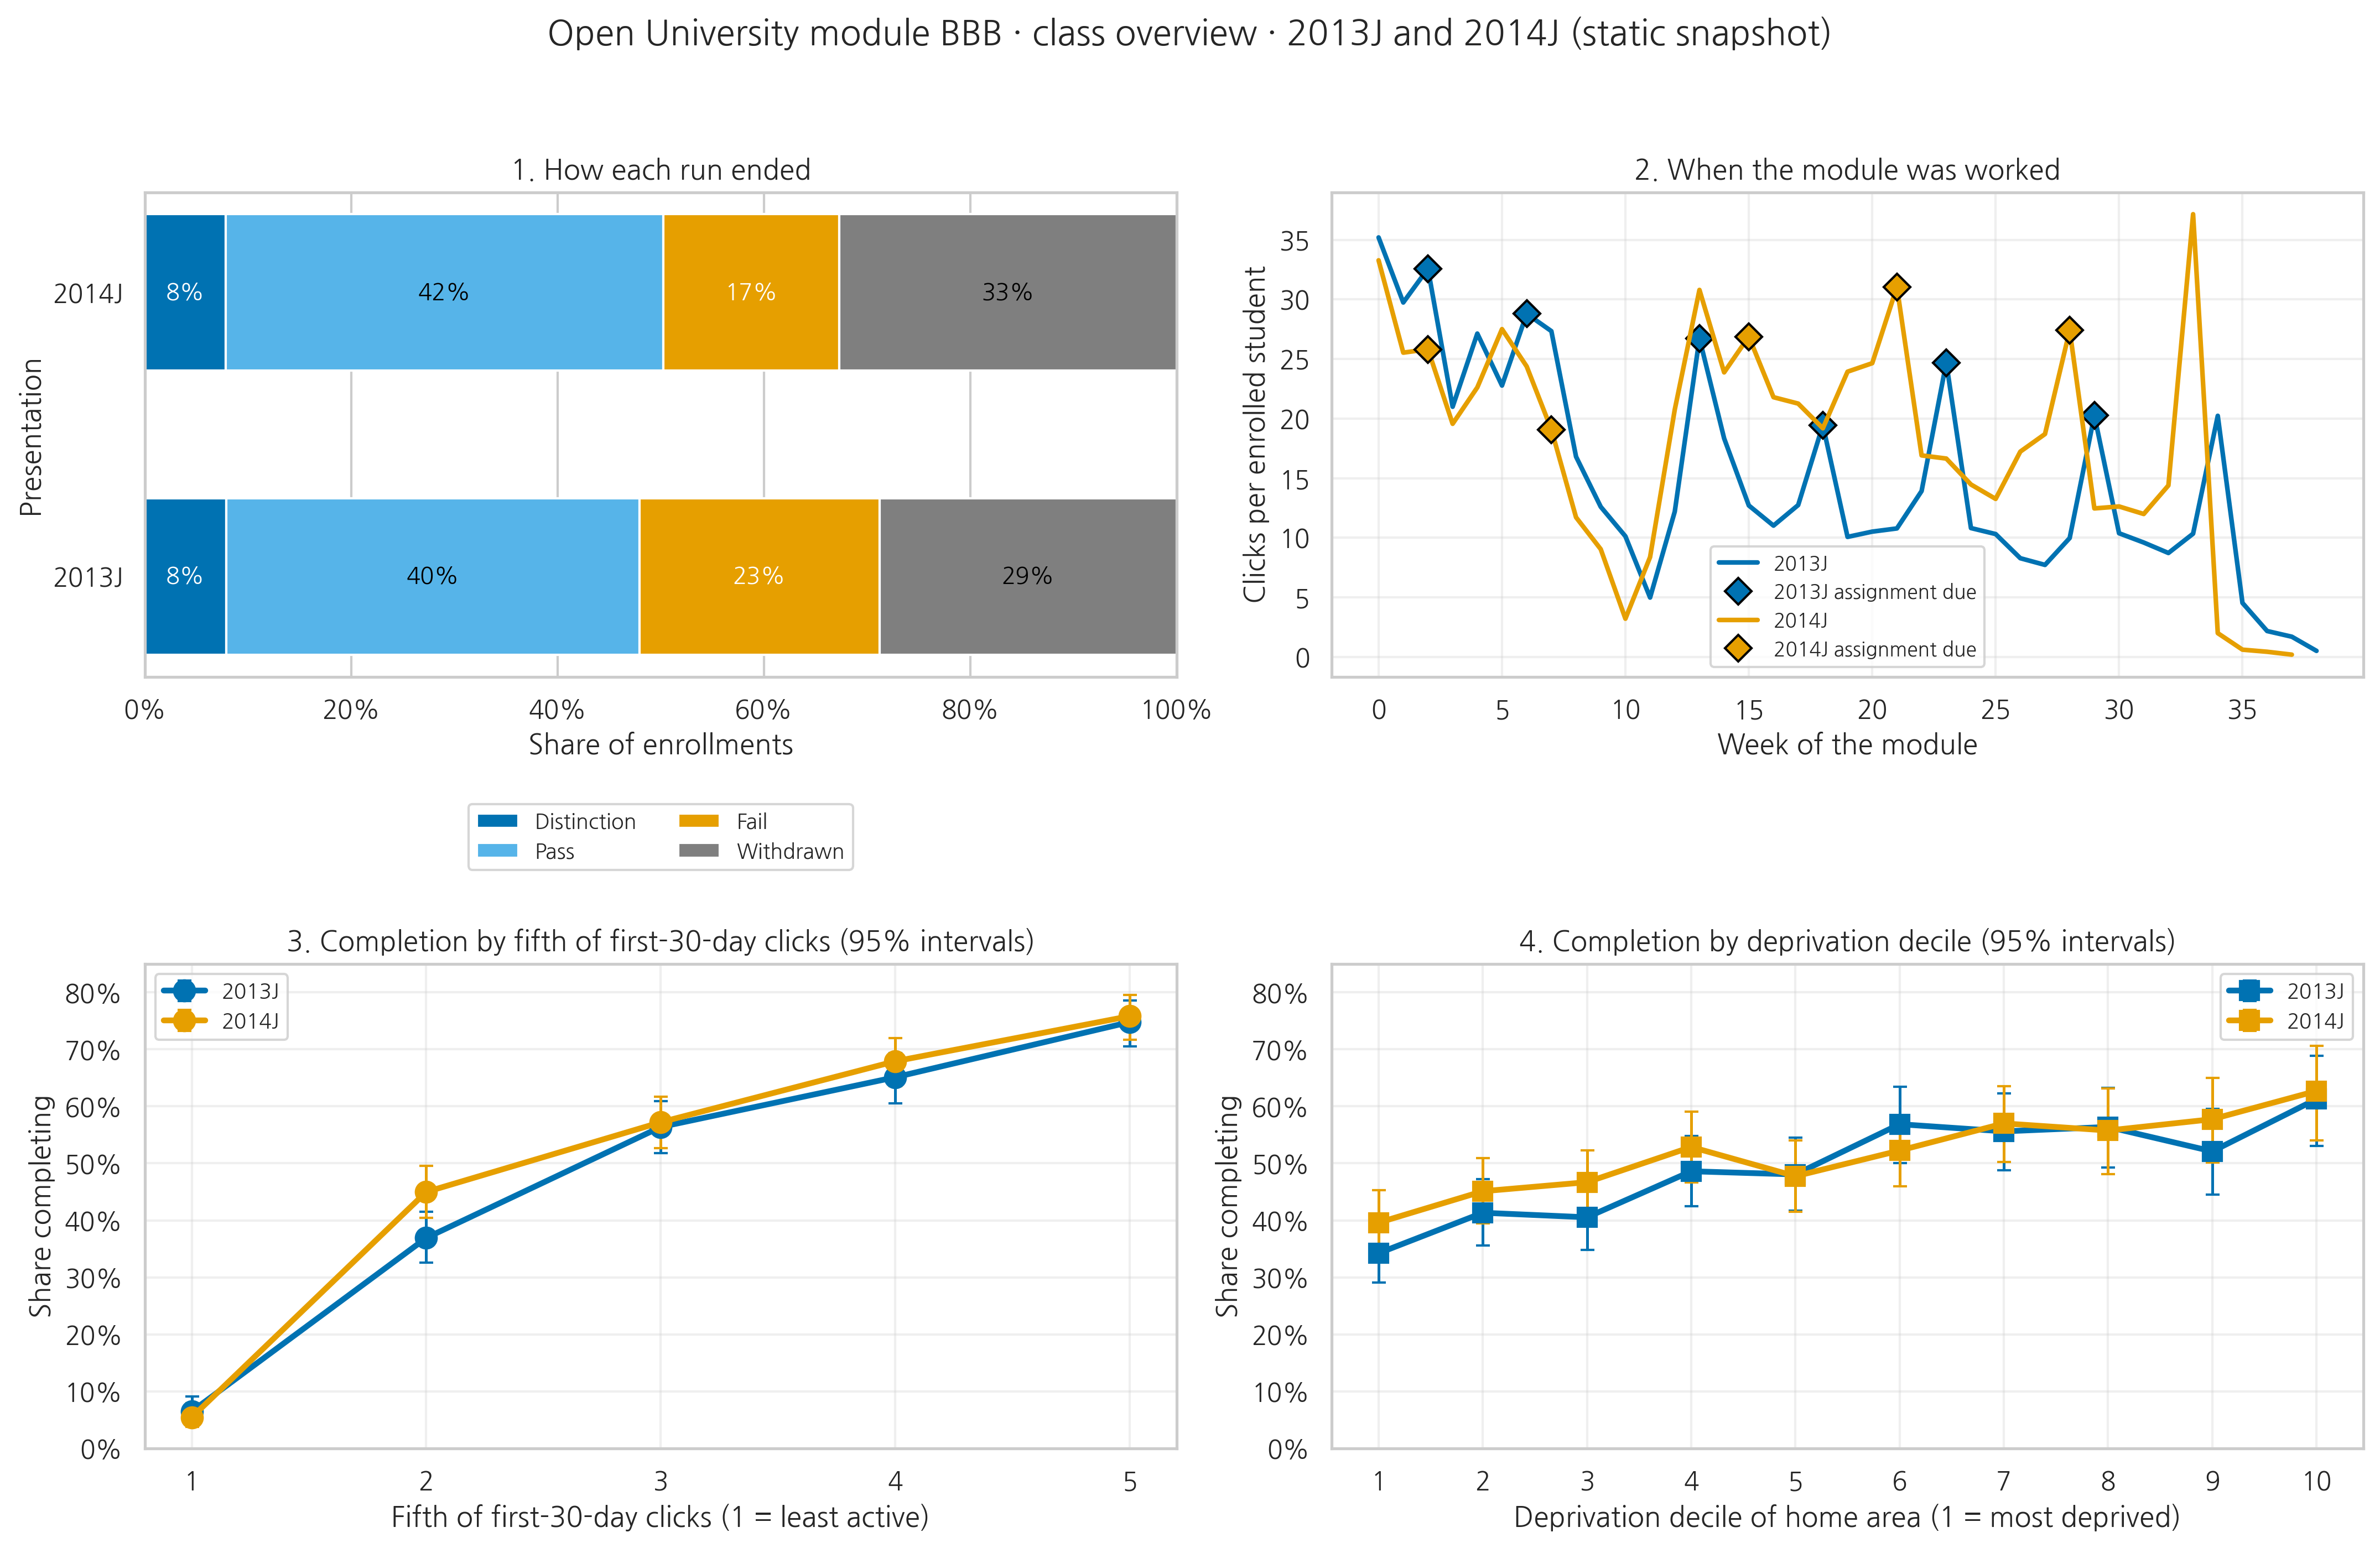

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.5))

# --- 1. outcome composition -------------------------------------------------
ax = axes[0, 0]
left = np.zeros(len(outcome_share))
ypos = np.arange(len(outcome_share))
for outcome in OUTCOMES:
    vals = outcome_share[outcome].values
    ax.barh(ypos, vals, left=left, color=OUTCOME_COLOR[outcome], edgecolor="white",
            label=outcome, height=0.55)
    for y, (l, v) in enumerate(zip(left, vals)):
        if v > 0.06:
            ax.text(l + v / 2, y, f"{v:.0%}", ha="center", va="center", fontsize=10,
                    color="white" if outcome in ("Distinction", "Fail") else "black")
    left = left + vals
ax.set_yticks(ypos); ax.set_yticklabels(outcome_share.index)
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("1. How each run ended", fontsize=12)
ax.set_xlabel("Share of enrollments")
ax.set_ylabel("Presentation")
ax.legend(fontsize=9, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.42))

# --- 2. weekly rhythm --------------------------------------------------------
ax = axes[0, 1]
for pres in PRESENTATIONS:
    s = weekly_per_student[pres].dropna()
    ax.plot(s.index, s.values, color=PRES_COLOR[pres], linewidth=2, label=pres)
    ax.plot(tma_weeks[pres], s.reindex(tma_weeks[pres]).values, "D",
            color=PRES_COLOR[pres], markersize=8, markeredgecolor="black", linestyle="none",
            label=f"{pres} assignment due")
ax.set_title("2. When the module was worked", fontsize=12)
ax.set_xlabel("Week of the module")
ax.set_ylabel("Clicks per enrolled student")
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3); ax.set_axisbelow(True)

# --- 3. completion by early-activity fifth -----------------------------------
ax = axes[1, 0]
for pres in PRESENTATIONS:
    g = fifths[fifths["code_presentation"] == pres]
    ax.errorbar(g["fifth"].astype(int), g["completion"],
                yerr=[(g["completion"] - g["lo"]).to_numpy(),
                      (g["hi"] - g["completion"]).to_numpy()],
                marker="o", markersize=9, linewidth=2.5, color=PRES_COLOR[pres],
                capsize=3, elinewidth=1.2, label=pres)
ax.set_ylim(0, 0.85); ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_title("3. Completion by fifth of first-30-day clicks (95% intervals)", fontsize=12)
ax.set_xlabel("Fifth of first-30-day clicks (1 = least active)")
ax.set_ylabel("Share completing")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_axisbelow(True)

# --- 4. completion by deprivation decile -------------------------------------
ax = axes[1, 1]
for pres in PRESENTATIONS:
    g = by_imd[by_imd["code_presentation"] == pres]
    ax.errorbar(g["imd_decile"], g["completion"],
                yerr=[(g["completion"] - g["lo"]).to_numpy(),
                      (g["hi"] - g["completion"]).to_numpy()],
                marker="s", markersize=8, linewidth=2.5, color=PRES_COLOR[pres],
                capsize=3, elinewidth=1.2, label=pres)
ax.set_ylim(0, 0.85); ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xticks(range(1, 11))
ax.set_title("4. Completion by deprivation decile (95% intervals)", fontsize=12)
ax.set_xlabel("Deprivation decile of home area (1 = most deprived)")
ax.set_ylabel("Share completing")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_axisbelow(True)

fig.suptitle("Open University module BBB · class overview · 2013J and 2014J "
             "(static snapshot)", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Let's look at the output.** Please take a moment with the four panels before reading on, and then let's discuss.

**1. Chart 3.** The two presentations lie close together: the least active fifth completes at 6.5 percent in 2013J, 95 percent interval [4.5, 9.1], and 5.4 percent in 2014J, [3.7, 7.9]; the most active fifth at 74.8 percent [70.6, 78.6] and 75.8 percent [71.7, 79.5]. Both runs show the same direction and similar rates. Does having a second run make the pattern more actionable, or only more reliable?

**2. Chart 4** shows the same direction in both runs, and it is a different kind of finding. Completion rises about 2.7 points per decile step in 2013J, 95 percent interval [2.0, 3.5], and 2.2 points [1.4, 2.9] in 2014J. At the ends of the 2013J line, the most deprived decile completes at 34.2 percent, [29.1, 39.8] on 298 enrollments, and the least deprived at 61.3 percent, [53.1, 68.9] on 142. The slope is the quantity reported, and its interval excludes zero in both runs.

| | |
|---|---|
| **What the data directly show** | Recorded completion in this module rose across the ten area-deprivation deciles in both runs, by about 2.7 points per step in 2013J and 2.2 in 2014J, on decile groups of 126 to 302 enrollments |
| **A plausible interpretation** | Study conditions that a neighborhood index partly stands in for, such as hours of paid work, quiet space, connectivity, and the cost of materials; features of how this module was taught, assessed, and supported; who chose to register in each area in the first place |
| **What these files cannot establish** | Which of those produced the gradient, and anything about the students as people. The index scores an area rather than a person, and the file records nothing about the household |

This chart uses no clickstream: it is recorded completion by area decile. What would it mean for a module team to put it on a screen every Monday?

*Connecting to the readings.* van Leeuwen, Teasley, and Wise (2022) point out that much of what a display means comes from what it compares the viewer to: their own past, a goal, the class, an expert model. Chart 4 chooses an area-deprivation band. What does that choice invite a teacher to do next?

**3. Chart 1** separates Withdrawn from Fail, where most dashboards merge the two into "not passing." What is one teaching decision that would change depending on which of those two a student is heading for?

**4.** If there were room for only three of these four charts, which would you cut, and on what grounds?


## Part C. The early warning panel

The class overview describes the module. This panel names people.

The model underneath it reads the first 30 days and the first assignment. Three columns go in: `clicks_first30`; `tma1_score_filled`, the score on the first tutor-marked assignment; and `tma1_submitted`, an indicator saying whether that score is a measurement or a fill. `active_days_first30` is left out, on this argument: a count of how many separate days contain activity reads the shape of a week, and the shape of a week is set by employment and caring hours that OULAD does not record. Results banked from an earlier presentation are set aside. A second model using clicks and active days is fitted alongside so the two can be compared, and the shipped one goes on the screen.

**Appendix B holds the evidence for leaving that column out, and says how weak it is.**

### Four decisions that are not settled

- **How many names appear.** This presentation has 2,237 enrollments. The panel assumes an outreach team that can make a limited number of calls in a week and shows **150**, a caseload rather than a diagnosis. That number comes from a resourcing decision and not from the model.
- **Whether the panel explains itself.** A flag with no reason attached gives a teacher a name and nothing else. Each risk score is decomposed into what each feature contributed, so the panel can say *why* a name is on the list.
- **What it is being compared against.** A list that is right 97 percent of the time sounds like a model working. The model card asks what the same caseload would have caught with no model at all, using one column a registrar could read off a spreadsheet, and prints both numbers side by side.
- **What is checked before it ships.** A list can be accurate and still fall unevenly, so the panel is audited by deprivation decile before anyone is contacted, and that audit is drawn on the dashboard itself rather than placed in an appendix. Part E then asks whether the fairness statistic everybody reports is even computable at this caseload.

### How the reason column works

A logistic regression turns standardized features into log-odds by multiplying each one by a coefficient. An enrollment one standard deviation below the class mean on assignment 1 score, where the coefficient is negative, receives a positive push toward being flagged. Adding those pushes across features gives the score, so the largest positive push is a defensible answer to "why is this name here."

Every predicted probability below is **out of sample**: each enrollment is scored by a model trained on the other four fifths of the class, so nobody is scored by a model that already saw how their term ended. And it is a predicted probability of a registry outcome, not a probability about anybody's future. Day 30 is the earliest day the features exist, not the earliest day this model could have been built, because the training labels are this presentation's own recorded outcomes.

**Run the cell below.** It fits both models, prints a model card, and prints the top of the flag list.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold

# ---- the term this dashboard is for ----------------------------------------
term = dash[dash["code_presentation"] == FOCAL_TERM].reset_index(drop=True).copy()
y_true = term["did_not_pass"].to_numpy()

# active_days is deliberately left out. See the Part C section above.
AUDITED_FEATURES = ["clicks_first30", "tma1_score_filled", "tma1_submitted"]
RETIRED_FEATURES = ["clicks_first30", "active_days_first30"]
CASELOAD = 150      # how many students the retention team can actually reach in a week

FEATURE_LABEL = {"clicks_first30":      "Clicks recorded, days 0 to 29",
                 "active_days_first30": "Active days, days 0 to 29",
                 "tma1_score_filled":   "Assignment 1 score",
                 "tma1_submitted":      "Assignment 1 was submitted"}

def risk_scores(feature_names, seed=8100):
    """Out-of-sample predicted probability of did_not_pass, from 5-fold cross validation."""
    X = term[list(feature_names)].to_numpy(dtype=float)
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    return cross_val_predict(pipe, X, y_true, cv=folds, method="predict_proba")[:, 1]

def flag_top_k(scores, k):
    """The caseload rule: flag the k highest scores. Ties are broken by row order."""
    flags = np.zeros(len(scores), dtype=int)
    flags[np.argsort(-scores, kind="stable")[:k]] = 1
    return flags

scores_audited = risk_scores(AUDITED_FEATURES)
scores_retired = risk_scores(RETIRED_FEATURES)
flags_audited  = flag_top_k(scores_audited, CASELOAD)
flags_retired  = flag_top_k(scores_retired, CASELOAD)

# ---- the fairness check -----------------------------------------------------
deprived = (term["imd_group"] == "Most deprived 30%").to_numpy()
rest     = (term["imd_group"] == "Rest of the class").to_numpy()

def false_positive_rate(flags, mask):
    """Share of the enrollments in this group that COMPLETED and got flagged anyway.

    The denominator comes before the rate: at this caseload, on a class where about
    half the enrollments did not complete, almost nobody who completed is flagged,
    so this rate sits near zero for any model and the subgroup counts are tiny.
    Part E returns to whether it can carry the weight people put on it.
    """
    completed_here = mask & (y_true == 0)
    return float(flags[completed_here].mean())


def false_positive_count(flags, mask):
    """The number the rate above is really made of."""
    completed_here = mask & (y_true == 0)
    return int(flags[completed_here].sum()), int(completed_here.sum())

def list_share_deprived(flags):
    return float((term.loc[flags == 1, "imd_group"] == "Most deprived 30%").mean())


def flag_rate_ratio(flags, m1, m2):
    """How many times more often group 1 is flagged than group 2, with a 95% interval.

    The interval is the standard one for a ratio of two proportions, computed on the
    log scale because a ratio is not symmetric around its point estimate. Unlike the
    false positive rate above, this one rests on the flag counts printed below, so it
    can be read.
    """
    a, na = int(flags[m1].sum()), int(m1.sum())
    b, nb = int(flags[m2].sum()), int(m2.sum())
    ratio = (a / na) / (b / nb)
    se = np.sqrt(1 / a - 1 / na + 1 / b - 1 / nb)
    return ratio, ratio * np.exp(-1.96 * se), ratio * np.exp(1.96 * se), a, na, b, nb

# ---- per-student reasons ----------------------------------------------------
X_full = term[AUDITED_FEATURES].to_numpy(dtype=float)
explain = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_full, y_true)
scaler = explain.named_steps["standardscaler"]
logreg = explain.named_steps["logisticregression"]
coefs = logreg.coef_[0]
contrib = pd.DataFrame(scaler.transform(X_full) * coefs,
                       columns=AUDITED_FEATURES, index=term["id_student"])
# The contributions come off a model fitted on the whole term; the scores on the
# screen are cross-validated. How far apart the two are is measured here rather
# than asserted, because the markdown above quotes it.
_full_fit = explain.predict_proba(X_full)[:, 1]
_gap_max = float(np.abs(_full_fit - scores_audited).max())
_gap_mean = float(np.abs(_full_fit - scores_audited).mean())

def reason_sentence(i, feature):
    value = term.loc[i, feature]
    if feature in ("tma1_score_filled", "tma1_submitted"):
        if term.loc[i, "tma1_submitted"] == 0:
            return "No assignment 1 recorded as submitted"
        # Not "class median": this median is over the enrollments that submitted.
        return (f"Assignment 1 score {value:.0f} (median {term['tma1_score'].median():.0f} "
                f"among the {int(term['tma1_submitted'].sum()):,} who submitted)")
    if feature == "clicks_first30":
        return f"{int(value):,} clicks recorded in the first 30 days"
    return f"Recorded activity on {int(value)} of the first 30 days"

flagged = term.loc[flags_audited == 1].copy()
flagged["risk_score"] = scores_audited[flags_audited == 1]
lead_feature = contrib.loc[flagged["id_student"]].idxmax(axis=1).to_numpy()
flagged["lead_feature"] = lead_feature
flagged["leading_reason"] = [reason_sentence(i, f) for i, f in zip(flagged.index, lead_feature)]
flagged = flagged.sort_values("risk_score", ascending=False).reset_index(drop=True)

print("=" * 92)
print("  MODEL CARD")
print("=" * 92)
print(f"  Presentation .............. BBB {FOCAL_TERM}, {len(term):,} enrollments")
print(f"  Features in use ........... {', '.join(FEATURE_LABEL[f] for f in AUDITED_FEATURES)}")
print(f"  Data window ............... days 0 to {EARLY_WINDOW - 1}, plus assignment 1 "
      f"(due day {tma1_day[FOCAL_TERM]:.0f})")
print( "  Algorithm ................. logistic regression, 5-fold cross-validated scores")
print(f"  Flag rule ................. the {CASELOAD} highest predicted probabilities "
      f"(one week of outreach)")
print( "  Label being predicted ..... did_not_pass: final_result is Fail or Withdrawn")
print(f"  Base rate ................. {y_true.mean():.1%} of the class "
      f"({y_true.sum():,} enrollments ended in Fail or Withdraw)")
print( "  Coefficients (log-odds per standard deviation):")
for f, c in zip(AUDITED_FEATURES, coefs):
    print(f"      {FEATURE_LABEL[f]:<28} {c:+.3f}   (a higher value "
          f"{'raises' if c > 0 else 'lowers'} the predicted probability)")

tp = int(((flags_audited == 1) & (y_true == 1)).sum())
fp = int(((flags_audited == 1) & (y_true == 0)).sum())
missed = int(((flags_audited == 0) & (y_true == 1)).sum())
print("\n  HOW THE LIST PERFORMS")
print(f"      of the {CASELOAD} flagged, went on to Fail or Withdraw . {tp}   ({tp / CASELOAD:.1%})")
print(f"      of the {CASELOAD} flagged, went on to complete .......... {fp}")
print(f"      did not complete, and the list never mentions ... {missed:,} of {int(y_true.sum()):,}"
      f"   (reach: {tp / y_true.sum():.1%})")
print(f"      same caseload, retired activity-only model ...... "
      f"{int(((flags_retired == 1) & (y_true == 1)).sum())} correct of {CASELOAD}")

# The comparison a precision figure is meaningless without. Not "compared to chance",
# which no one would propose, but compared to the simplest rule a registrar could run.
rule = (term["tma1_submitted"] == 0).to_numpy()
rule_n, rule_bad = int(rule.sum()), int(y_true[rule].sum())
print("\n  COMPARED TO WHAT")
print(f"      naming {CASELOAD} enrollments at random would be right ..... {y_true.mean():.1%}")
print(f"      one rule, no model: 'no assignment 1 recorded as submitted'")
print(f"          enrollments matching it ..................... {rule_n}")
print(f"          of those, ended in Fail or Withdraw ......... {rule_bad}   ({rule_bad / rule_n:.1%})")
print(f"          so any {CASELOAD} names drawn from that group are right .. {rule_bad / rule_n:.1%}")
print(f"      the model's {CASELOAD} names are right ................... {tp / CASELOAD:.1%}")
print(f"      of the {CASELOAD} the model flagged, how many match the rule  "
      f"{int(rule[flags_audited == 1].sum())}")
print("      The regression is ranking inside a single indicator and, at this")
print("      caseload, is not adding to it. Chance is the wrong baseline. The")
print("      one-column rule is the baseline.")

print("\n  THE FAIRNESS AUDIT, RUN ON THE LIST THAT IS ABOUT TO BE SENT")
n_dep_list = int((term.loc[flags_audited == 1, "imd_group"] == "Most deprived 30%").sum())
print(f"      most deprived 30% share of the class ............ {deprived.mean():.1%}"
      f"   ({int(deprived.sum()):,} of {len(term):,})")
print(f"      most deprived 30% share of the FLAG LIST ........ {list_share_deprived(flags_audited):.1%}"
      f"   ({n_dep_list} of {CASELOAD})")
rr, rr_lo, rr_hi, a_, na_, b_, nb_ = flag_rate_ratio(flags_audited, deprived, rest)
print(f"      flag rate, most deprived 30% ................... {a_ / na_:.1%}   ({a_} of {na_:,})")
print(f"      flag rate, rest of the class ................... {b_ / nb_:.1%}   ({b_} of {nb_:,})")
print(f"      ratio between them ............................. {rr:.2f}"
      f"   95% [{rr_lo:.2f}, {rr_hi:.2f}]")
print("      That interval clears 1, so the skew in WHO GETS FLAGGED is larger than")
print("      the noise. It is also wide: this is one caseload of 150 names.")
n_dep_list_ret = int((term.loc[flags_retired == 1, "imd_group"] == "Most deprived 30%").sum())
overlap_lists = len(set(term.loc[flags_audited == 1, "id_student"]) &
                    set(term.loc[flags_retired == 1, "id_student"]))
print(f"\n      the retired model's list, for contrast ......... {n_dep_list_ret} of {CASELOAD}"
      f"   ({list_share_deprived(flags_retired):.1%})")
_p1, _p2 = n_dep_list / CASELOAD, n_dep_list_ret / CASELOAD
_se = np.sqrt(_p1 * (1 - _p1) / CASELOAD + _p2 * (1 - _p2) / CASELOAD)
print(f"      difference between the two lists ............... {_p1 - _p2:+.1%}"
      f"   95% [{_p1 - _p2 - 1.96 * _se:+.1%}, {_p1 - _p2 + 1.96 * _se:+.1%}]")
print(f"      names the two lists share ...................... {overlap_lists} of {CASELOAD}")
print("      That difference is not readable here. Two lists of 150 that agree on fewer than")
print("      a third of their names cannot be separated on a share statistic, and the")
print("      interval says so. This comparison does not establish which list is less skewed.")
fp_dep_a, n_dep_a = false_positive_count(flags_audited, deprived)
fp_rest_a, n_rest_a = false_positive_count(flags_audited, rest)
fp_dep_r, _ = false_positive_count(flags_retired, deprived)
fp_rest_r, _ = false_positive_count(flags_retired, rest)
print(f"\n      false positive rate gap, shipped model ......... "
      f"{false_positive_rate(flags_audited, deprived) - false_positive_rate(flags_audited, rest):+.4f}"
      f"   <- built from {fp_dep_a} and {fp_rest_a} false positives")
print(f"      false positive rate gap, retired model ......... "
      f"{false_positive_rate(flags_retired, deprived) - false_positive_rate(flags_retired, rest):+.4f}"
      f"   <- built from {fp_dep_r} and {fp_rest_r} false positives")
print()
print("      Both gaps are computed from single-digit event counts.")
print("      A four-decimal number resting on three or four people is not a measurement")
print("      of fairness. Notice which of the numbers on this screen came with an")
print("      interval and which could not.")
print(f"\n      The reason column is read off a model fitted on the whole term, while the")
print(f"      scores are cross-validated. Across the {len(term):,} enrollments the two")
print(f"      differ by at most {_gap_max:.3f} and by {_gap_mean:.3f} on average.")
print(f"\n      ({int((term['imd_group'] == 'Not recorded').sum())} enrollments have no "
      f"deprivation band. They are inside the two share")
print("      denominators above and outside the two flag rates, which is the effect")
print("      decision 2 in Part A described.)")
print("=" * 92)

print(f"\nTOP 15 OF THE {CASELOAD} ENROLLMENTS FLAGGED THIS WEEK\n")
show = flagged.head(15)[["id_student", "risk_score", "clicks_first30",
                         "active_days_first30", "leading_reason", "final_result"]]
print(show.assign(risk_score=lambda d: d["risk_score"].round(4)).to_string(index=False))
print("\nThe risk_score column is the one to read. The top of the list agrees to three or four decimal")
print("places, and the order inside that block was decided by which cross-validation")
print("fold each enrollment landed in and, within a fold, by row order, not by anything")
print("about the people.")
print("The panel below will draw them as a ranked list anyway.")

  MODEL CARD
  Presentation .............. BBB 2013J, 2,237 enrollments
  Features in use ........... Clicks recorded, days 0 to 29, Assignment 1 score, Assignment 1 was submitted
  Data window ............... days 0 to 29, plus assignment 1 (due day 19)
  Algorithm ................. logistic regression, 5-fold cross-validated scores
  Flag rule ................. the 150 highest predicted probabilities (one week of outreach)
  Label being predicted ..... did_not_pass: final_result is Fail or Withdrawn
  Base rate ................. 52.1% of the class (1,165 enrollments ended in Fail or Withdraw)
  Coefficients (log-odds per standard deviation):
      Clicks recorded, days 0 to 29 -0.302   (a higher value lowers the predicted probability)
      Assignment 1 score           -1.555   (a higher value lowers the predicted probability)
      Assignment 1 was submitted   -0.173   (a higher value lowers the predicted probability)

  HOW THE LIST PERFORMS
      of the 150 flagged, went on to Fai

**Run the cell below** to draw the panel.

The top row is the list a teacher would act on: the fifteen highest scores, and beside them the same fifteen enrollments with the score broken into the three feature contributions, in log-odds. A bar pointing right is a push toward being flagged, a bar pointing left is a pull away from it, and the length is how hard the push was. The right half is the part most early warning systems in the field do not show, and it is the part that lets a teacher question a flag.

The bottom row is what belongs on the same screen if anybody is going to be able to question the list. On the left, where the caseload cutoff falls in the distribution of predicted probabilities across the whole class. On the right, the flag rate in each deprivation decile with the recorded non-completion rate for that decile drawn over it, both with 95 percent intervals. Each decile holds between 142 and 298 enrollments and between 7 and 26 flags, so most neighboring bars overlap, and the direction of the whole line is the part chart 4 supports.

The right edge of the bottom-left chart is the 422 enrollments with near-identical scores. Part E item 3 returns to it.


In [8]:
# ---- inputs for the panel ---------------------------------------------------
top_n = 15
top = flagged.head(top_n)
row_labels = [f"enrollment {sid}" for sid in top["id_student"]]
y_pos = list(range(top_n))[::-1]                     # highest risk at the top
contrib_top = contrib.loc[top["id_student"]]
bar_colors = {"clicks_first30": SKY, "tma1_score_filled": PURPLE,
              "tma1_submitted": ORANGE}

cutoff_score = float(np.sort(scores_audited)[-CASELOAD])

audit_tbl = (pd.DataFrame({"decile": term["imd_decile"], "flag": flags_audited,
                           "did_not_pass": y_true})
             .dropna(subset=["decile"])
             .groupby("decile")
             .agg(students=("flag", "size"), flags=("flag", "sum"),
                  flag_rate=("flag", "mean"), did_not_pass=("did_not_pass", "sum"),
                  did_not_pass_rate=("did_not_pass", "mean")).reset_index())
# Ten deciles is ten comparisons, and each flag rate here rests on a small number of
# flags, printed below. Carry the interval onto the chart or nobody can read one bar
# against the next. wilson() was defined in Part B.
for count_col, stem in [("flags", "flag"), ("did_not_pass", "did_not_pass")]:
    lo_hi = [wilson(k, n) for k, n in zip(audit_tbl[count_col], audit_tbl["students"])]
    audit_tbl[stem + "_lo"] = [a for a, _ in lo_hi]
    audit_tbl[stem + "_hi"] = [b for _, b in lo_hi]

print("FLAGS PER DEPRIVATION DECILE, the counts under chart 4 below")
print(audit_tbl[["decile", "students", "flags", "flag_rate", "did_not_pass"]]
      .assign(decile=lambda d: d["decile"].astype(int),
              flag_rate=lambda d: d["flag_rate"].round(3)).to_string(index=False))
print(f"  Flags per decile run from {int(audit_tbl['flags'].min())} to "
      f"{int(audit_tbl['flags'].max())}, on {int(audit_tbl['students'].min())} to "
      f"{int(audit_tbl['students'].max())} enrollments.\n")

fig = make_subplots(
    rows=2, cols=2, vertical_spacing=0.17, horizontal_spacing=0.06,
    column_widths=[0.42, 0.58],
    subplot_titles=(f"1. Top {top_n} of the {CASELOAD} flagged: model score",
                    "2. Why: contribution of each feature (log-odds)",
                    f"3. Where the caseload cutoff falls ({len(term):,} enrollments)",
                    "4. Fairness audit: flag rate by deprivation decile (95% intervals)"),
)

# --- 1. risk score bars ------------------------------------------------------
fig.add_trace(go.Bar(
    x=top["risk_score"], y=y_pos, orientation="h", marker_color=BLUE,
    text=[f"{v:.4f}" for v in top["risk_score"]], textposition="outside",
    name="Model score", showlegend=False, customdata=top["leading_reason"],
    hovertemplate="risk %{x:.4f}<br>%{customdata}<extra></extra>"), row=1, col=1)

# --- 2. contributions --------------------------------------------------------
for feature in AUDITED_FEATURES:
    values = contrib_top[feature].to_numpy()
    raw = term.set_index("id_student").loc[top["id_student"], feature].to_numpy()
    fig.add_trace(go.Bar(
        x=values, y=y_pos, orientation="h", name=FEATURE_LABEL[feature],
        marker_color=bar_colors[feature], customdata=raw,
        hovertemplate=FEATURE_LABEL[feature] + " = %{customdata:.0f}"
                      "<br>contribution %{x:+.2f}<extra></extra>"), row=1, col=2)

# --- 3. risk score distribution ---------------------------------------------
fig.add_trace(go.Histogram(
    x=scores_audited, xbins=dict(start=0, end=1, size=0.02), marker_color=GREY,
    name="Students", showlegend=False,
    hovertemplate="risk %{x}<br>%{y} students<extra></extra>"), row=2, col=1)
fig.add_vline(x=cutoff_score, line_dash="dash", line_color=VERM, row=2, col=1,
              annotation_text=f"caseload cutoff {cutoff_score:.3f}",
              annotation_position="top left")

# --- 4. the audit -----------------------------------------------------------
fig.add_trace(go.Bar(
    x=audit_tbl["decile"], y=audit_tbl["flag_rate"], marker_color=BLUE,
    name="Share flagged", customdata=audit_tbl[["students", "flags"]].to_numpy(),
    error_y=dict(type="data", symmetric=False, thickness=1.2, width=4, color="black",
                 array=(audit_tbl["flag_hi"] - audit_tbl["flag_rate"]).to_numpy(),
                 arrayminus=(audit_tbl["flag_rate"] - audit_tbl["flag_lo"]).to_numpy()),
    hovertemplate="decile %{x}: %{y:.1%} flagged<br>%{customdata[1]} of "
                  "%{customdata[0]} enrollments<extra></extra>"),
    row=2, col=2)
fig.add_trace(go.Scatter(
    x=audit_tbl["decile"], y=audit_tbl["did_not_pass_rate"], mode="lines+markers",
    line=dict(color=VERM, width=2.5), marker=dict(symbol="square", size=9),
    error_y=dict(type="data", symmetric=False, thickness=1.2, width=4, color=VERM,
                 array=(audit_tbl["did_not_pass_hi"] - audit_tbl["did_not_pass_rate"]).to_numpy(),
                 arrayminus=(audit_tbl["did_not_pass_rate"] - audit_tbl["did_not_pass_lo"]).to_numpy()),
    name="Share whose enrollment ended in Fail or Withdraw",
    hovertemplate="decile %{x}: %{y:.1%} did not complete<extra></extra>"), row=2, col=2)

fig.update_layout(barmode="relative", height=880, width=1180, template="simple_white",
                  title=dict(text=f"Open University BBB {FOCAL_TERM} · early warning · "
                                  f"{CASELOAD} enrollments flagged for outreach",
                             x=0.5, font=dict(size=19)),
                  legend=dict(orientation="h", yanchor="bottom", y=-0.11,
                              xanchor="center", x=0.5),
                  margin=dict(l=130, r=40, t=100, b=110))
fig.update_yaxes(tickmode="array", tickvals=y_pos, ticktext=row_labels, row=1, col=1,
                 tickfont=dict(size=10))
fig.update_yaxes(showticklabels=False, row=1, col=2)
fig.update_xaxes(title_text="Predicted probability that this enrollment ends in Fail or Withdraw",
                 range=[0, 1.18], row=1, col=1)
fig.update_xaxes(title_text="Push toward (right) or away from (left) being flagged",
                 row=1, col=2)
fig.add_vline(x=0, line_color="black", line_width=1, row=1, col=2)
fig.update_xaxes(title_text="Out-of-sample predicted probability", row=2, col=1)
fig.update_yaxes(title_text="Number of students", row=2, col=1)
fig.update_xaxes(title_text="Deprivation decile of home area (1 = most deprived)",
                 tickmode="array", tickvals=list(range(1, 11)), row=2, col=2)
fig.update_yaxes(title_text="Share of the decile", tickformat=".0%", row=2, col=2)
fig.show()

FLAGS PER DEPRIVATION DECILE, the counts under chart 4 below
 decile  students  flags  flag_rate  did_not_pass
      1       298     26      0.087           196
      2       271     23      0.085           159
      3       264     22      0.083           157
      4       251     15      0.060           129
      5       231     11      0.048           120
      6       204     13      0.064            88
      7       205     13      0.063            91
      8       188      8      0.043            82
      9       167     11      0.066            80
     10       142      7      0.049            55
  Flags per decile run from 7 to 26, on 142 to 298 enrollments.



**Run the cell below** for the static version, for readers on GitHub and for anyone printing this. Underneath it, three tallies not shown on the chart.

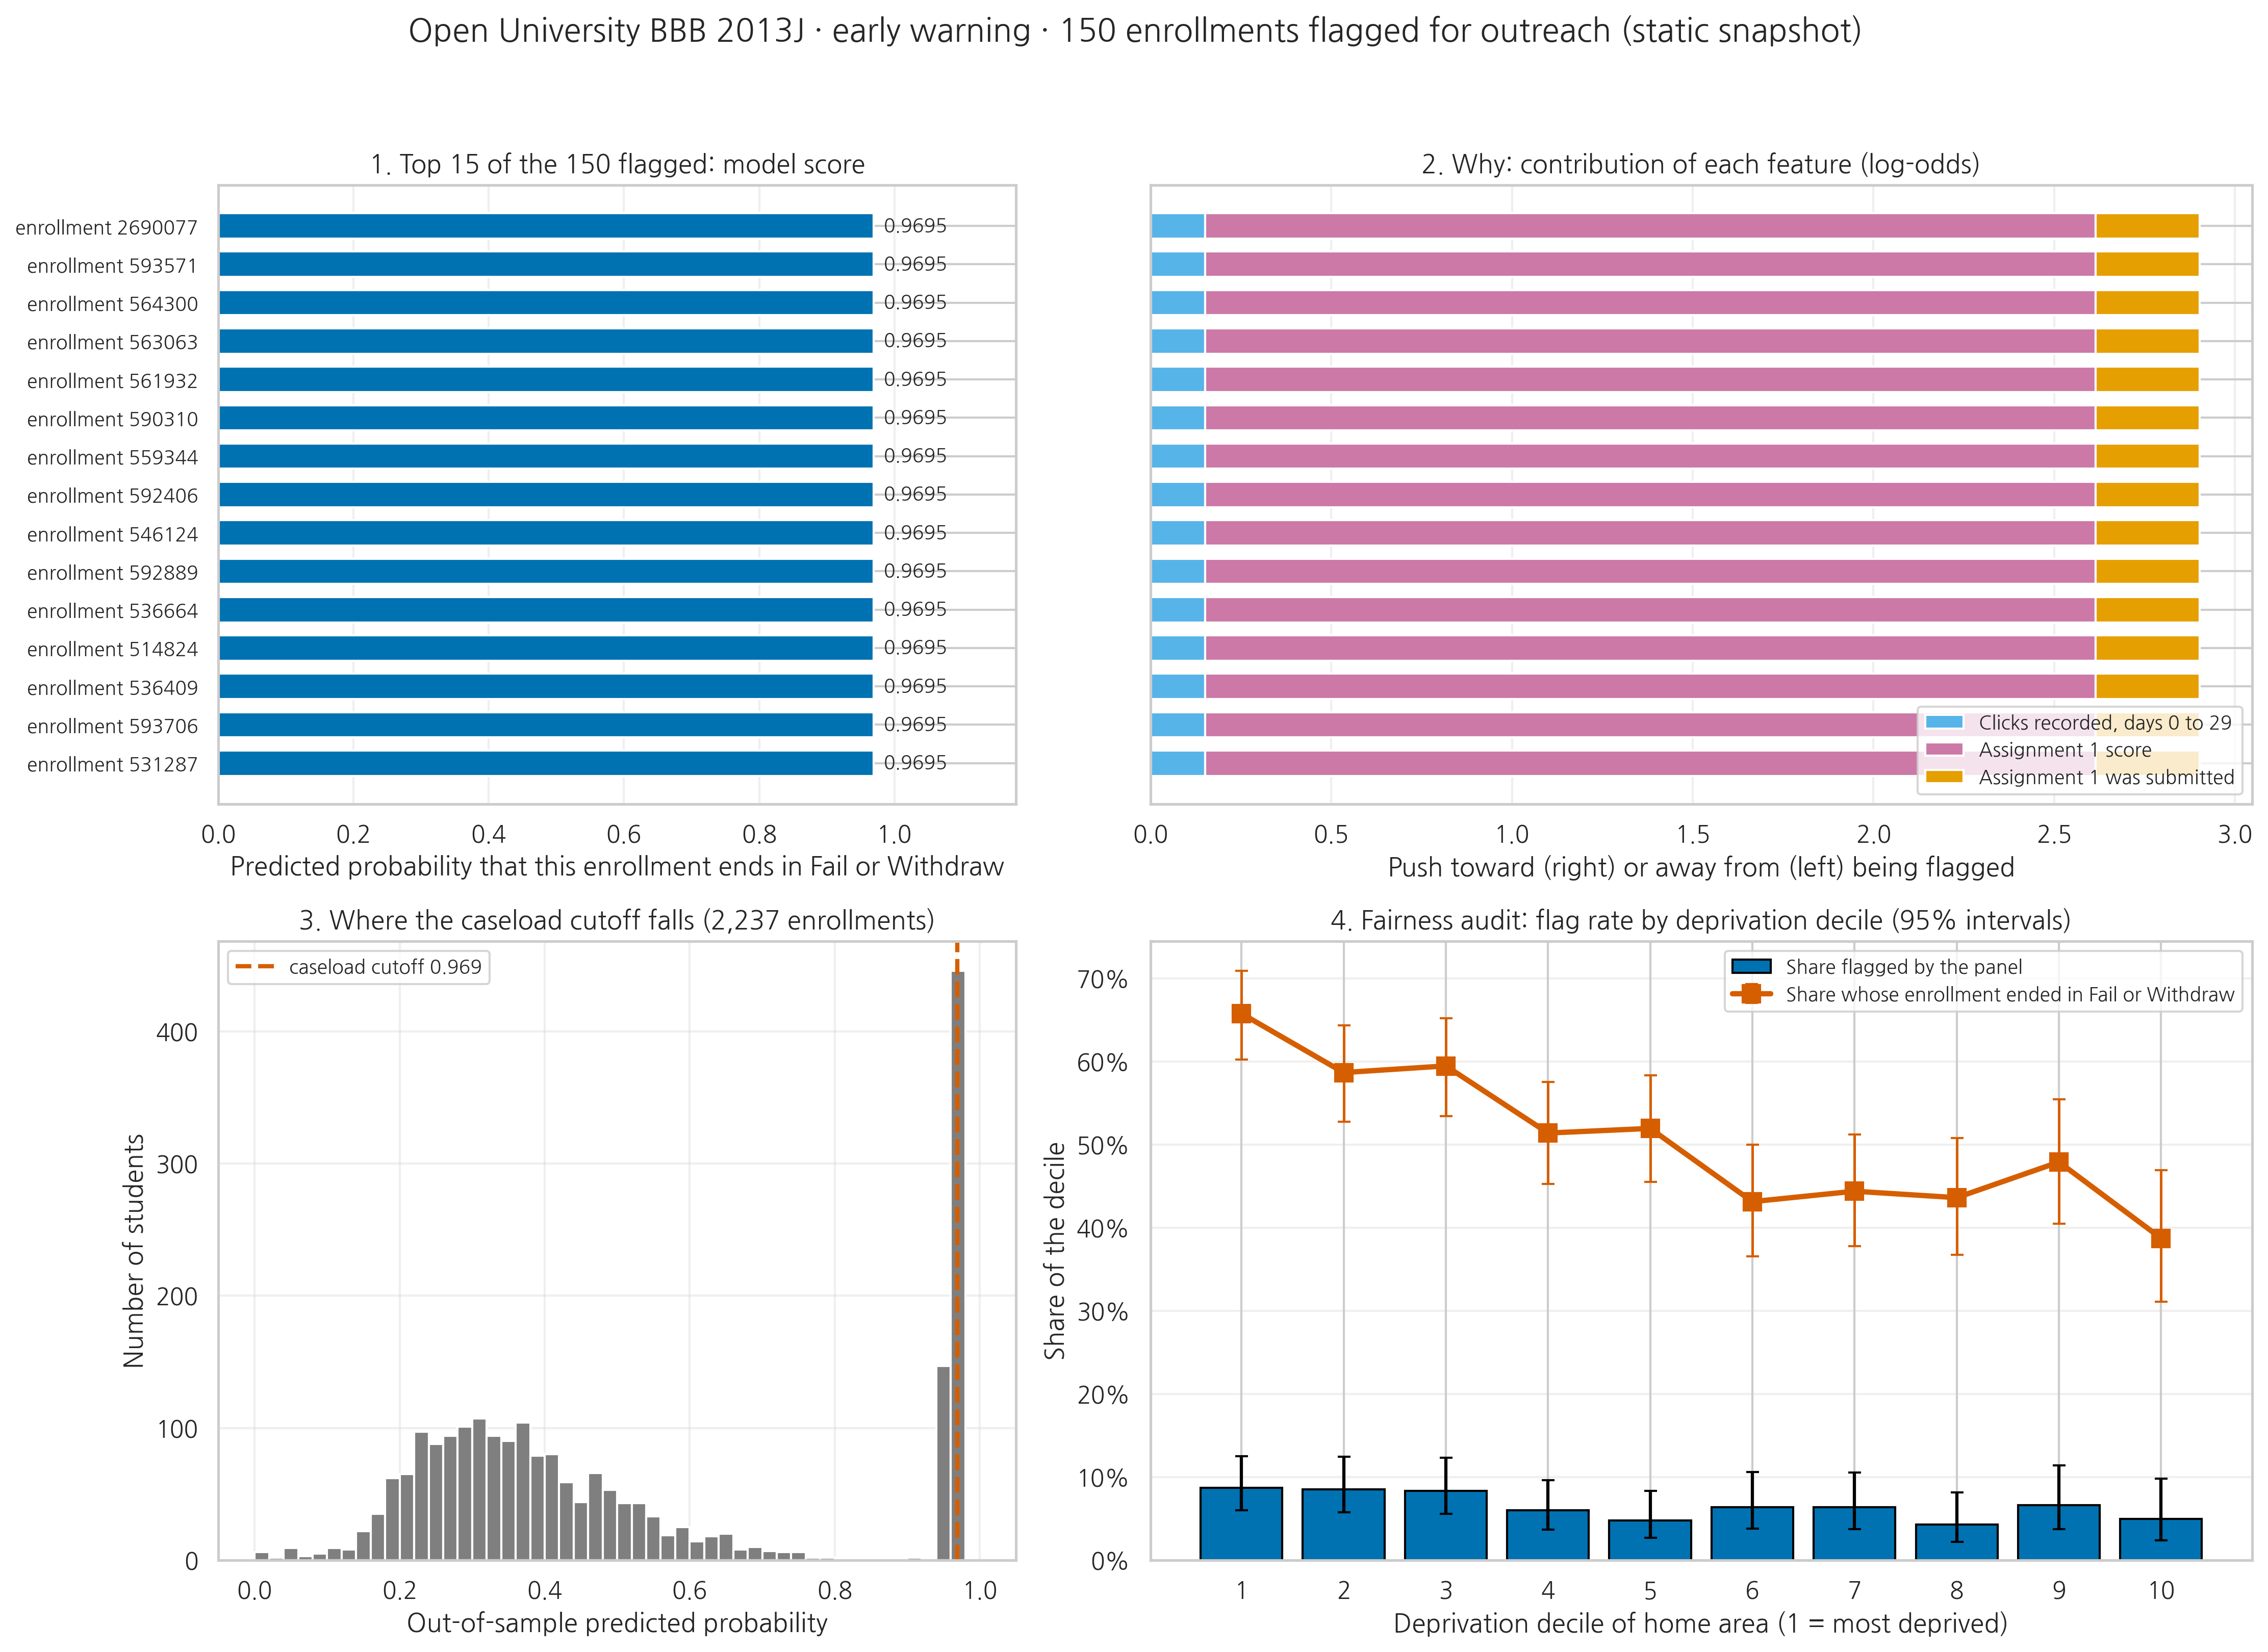

LEADING REASON, TALLIED ACROSS THE WHOLE FLAG LIST
  Assignment 1 score           150 of 150
  of which the reason printed is
  'No assignment 1 recorded as submitted'  150 of 150

ENROLLMENTS THE MODEL CANNOT TELL APART
  no recorded clicks in days 0 to 29 AND no assignment 1 ... 422 enrollments
  their predicted probabilities run from 0.9598 to 0.9695
  how many of the 150 flag slots they occupy .................. 140
  how many of them ended in Fail or Withdraw ......................... 413 of 422   (97.9%)
  The model has no information that separates them. What separates them on the
  screen is the sort order.

WHO IS ON THIS LIST
  flagged enrollments that had ALREADY unregistered by day 0 ... 103 of 150
  (336 enrollments in this term unregistered before day 1 and stayed in the roster)
  flagged enrollments already unregistered by day 30, the earliest
  day its features exist ...................................... 117 of 150
  (411 enrollments in this term had unregistered by th

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11),
                         gridspec_kw={"width_ratios": [0.42, 0.58]})
ypos = np.arange(top_n)

# --- 1. risk score ----------------------------------------------------------
ax = axes[0, 0]
ax.barh(ypos, top["risk_score"], color=BLUE, height=0.66)
for i, v in enumerate(top["risk_score"]):
    ax.text(v + 0.015, i, f"{v:.4f}", va="center", fontsize=9)
ax.set_yticks(ypos); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 1.18)
ax.set_title(f"1. Top {top_n} of the {CASELOAD} flagged: model score", fontsize=12)
ax.set_xlabel("Predicted probability that this enrollment ends in Fail or Withdraw")
ax.grid(axis="x", alpha=0.3); ax.set_axisbelow(True)

# --- 2. contributions --------------------------------------------------------
ax = axes[0, 1]
pos = np.zeros(top_n); neg = np.zeros(top_n)
for feature in AUDITED_FEATURES:
    v = contrib_top[feature].to_numpy()
    left = np.where(v >= 0, pos, neg)
    ax.barh(ypos, v, left=left, height=0.66, color=bar_colors[feature],
            edgecolor="white", label=FEATURE_LABEL[feature])
    pos = pos + np.clip(v, 0, None); neg = neg + np.clip(v, None, 0)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(ypos); ax.set_yticklabels([]); ax.invert_yaxis()
ax.set_title("2. Why: contribution of each feature (log-odds)", fontsize=12)
ax.set_xlabel("Push toward (right) or away from (left) being flagged")
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.3); ax.set_axisbelow(True)

# --- 3. risk distribution ----------------------------------------------------
ax = axes[1, 0]
ax.hist(scores_audited, bins=np.arange(0, 1.02, 0.02), color=GREY, edgecolor="white")
ax.axvline(cutoff_score, color=VERM, linestyle="--", linewidth=2,
           label=f"caseload cutoff {cutoff_score:.3f}")
ax.set_title(f"3. Where the caseload cutoff falls ({len(term):,} enrollments)", fontsize=12)
ax.set_xlabel("Out-of-sample predicted probability")
ax.set_ylabel("Number of students")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_axisbelow(True)

# --- 4. the audit ------------------------------------------------------------
ax = axes[1, 1]
ax.bar(audit_tbl["decile"], audit_tbl["flag_rate"], color=BLUE, edgecolor="black",
       yerr=[(audit_tbl["flag_rate"] - audit_tbl["flag_lo"]).to_numpy(),
             (audit_tbl["flag_hi"] - audit_tbl["flag_rate"]).to_numpy()],
       capsize=3, ecolor="black", label="Share flagged by the panel")
ax.errorbar(audit_tbl["decile"], audit_tbl["did_not_pass_rate"],
            yerr=[(audit_tbl["did_not_pass_rate"] - audit_tbl["did_not_pass_lo"]).to_numpy(),
                  (audit_tbl["did_not_pass_hi"] - audit_tbl["did_not_pass_rate"]).to_numpy()],
            color=VERM, marker="s", markersize=8, linewidth=2.5, capsize=3, elinewidth=1.2,
            label="Share whose enrollment ended in Fail or Withdraw")
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("4. Fairness audit: flag rate by deprivation decile (95% intervals)",
             fontsize=12)
ax.set_xlabel("Deprivation decile of home area (1 = most deprived)")
ax.set_ylabel("Share of the decile")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)

fig.suptitle(f"Open University BBB {FOCAL_TERM} · early warning · {CASELOAD} enrollments "
             "flagged for outreach (static snapshot)", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---- three tallies the chart cannot carry ----------------------------------
tally = flagged["lead_feature"].map(FEATURE_LABEL).value_counts()
print("LEADING REASON, TALLIED ACROSS THE WHOLE FLAG LIST")
for name, n in tally.items():
    print(f"  {name:<28} {n:>3} of {CASELOAD}")
n_never_submitted = int((flagged["tma1_submitted"] == 0).sum())
print(f"  of which the reason printed is")
print(f"  'No assignment 1 recorded as submitted'  {n_never_submitted:>3} of {CASELOAD}")

no_evidence = ((term["clicks_first30"] == 0) & (term["tma1_submitted"] == 0)).to_numpy()
print(f"\nENROLLMENTS THE MODEL CANNOT TELL APART")
print(f"  no recorded clicks in days 0 to {EARLY_WINDOW - 1} AND no assignment 1 ... "
      f"{int(no_evidence.sum())} enrollments")
print(f"  their predicted probabilities run from {scores_audited[no_evidence].min():.4f} to "
      f"{scores_audited[no_evidence].max():.4f}")
print(f"  how many of the {CASELOAD} flag slots they occupy .................. "
      f"{int(flags_audited[no_evidence].sum())}")
print(f"  how many of them ended in Fail or Withdraw ......................... "
      f"{int(y_true[no_evidence].sum())} of {int(no_evidence.sum())}"
      f"   ({y_true[no_evidence].mean():.1%})")
print("  The model has no information that separates them. What separates them on the")
print("  screen is the sort order.")

already_left = term["left_before_day_1"].to_numpy().astype(bool)
# The list cannot be drawn before day 30, because it reads days 0 to 29 and an
# assignment due on day 19. So day 30, not day 0, is the boundary that decides
# whether a name on it belongs to somebody a phone call could still reach.
still_at_30 = (term["date_unregistration"].isna() |
               (term["date_unregistration"] > EARLY_WINDOW)).to_numpy()
print(f"\nWHO IS ON THIS LIST")
print(f"  flagged enrollments that had ALREADY unregistered by day 0 ... "
      f"{int(flags_audited[already_left].sum())} of {CASELOAD}")
print(f"  ({int(already_left.sum())} enrollments in this term unregistered before day 1 "
      f"and stayed in the roster)")
print(f"  flagged enrollments already unregistered by day {EARLY_WINDOW}, the earliest")
print(f"  day its features exist ...................................... "
      f"{int(flags_audited[~still_at_30].sum())} of {CASELOAD}")
print(f"  ({int((~still_at_30).sum())} enrollments in this term had unregistered by then)")

**Let's look at the output.** Six things in those printouts.

**1. One feature supplies the leading reason for all 150 names:** no assignment 1 recorded as submitted. What has a teacher learned about their teaching after reading that same reason 150 times?

**2. 422 enrollments have no recorded clicks in the first 30 days and no assignment 1.** All three of their feature values are identical, so their scores differ only in the third and fourth decimal place, and that difference is which cross-validation fold they landed in. 140 of the 150 flag slots go to this group. Which 140? Whichever ones sorted to the top. Inside that block there is no ranking, only an ordering. What might the screen say instead of a rank?

**3. 103 of the 150 names carry an unregistration date on or before day 0, and 117 by day 30**, which is the earliest day the features exist.

| | |
|---|---|
| **What the data directly show** | 336 enrollments in this presentation record an unregistration date on or before day 0, and 411 by day 30; 103 and 117 of the 150 flagged names are among them |
| **A plausible interpretation** | Most of a week of outreach would be spent contacting people who had already left the module |
| **What these files cannot establish** | What an unregistration record meant in each case, whether any of those people later re-registered elsewhere, or whether contact would have been unwelcome, useful, or already attempted by somebody else |

Where in Part A did this become possible, and what would have had to change there?

**4. Chart 4 audits this list by deprivation decile,** and the printout holds a problem worth naming. The false positive rate gap looks tiny. Then read the counts: the shipped model's gap is built from 2 false positives against 2, and the activity-only model's from 4 against 6. At a caseload of 150 on a class where 1,165 enrollments ended in Fail or Withdraw, hardly anybody who completed is flagged at all, so this rate is held near zero by the flag rule itself. What would you report in its place?

**5.** Enrollments from the most deprived 30 percent of areas are flagged at 8.5 percent, 71 of 833, against 5.6 percent for the rest, 78 of 1,388: a ratio of 1.52 with a 95 percent interval of [1.11, 2.07]. That interval clears 1, so unlike the false positive gap this one has enough events under it to be read.

**6.** Chart 4 asked whether the model is fair. This panel raises two further questions: whether it is *useful*, and whether it is *doing anything*. It names 12.5 percent of the enrollments that go on to fail or withdraw, and its 150 names are right 97.3 percent of the time against 96.5 percent for the one-line rule "no assignment 1 recorded as submitted", which needs no model at all. The interval on 146 correct out of 150 contains the rule's rate, so at this caseload the two cannot be told apart on precision. Which of those three properties would a teacher notice first, and which would a vendor report?

*Connecting to the readings.* Wise and Jung (2019) describe instructional decision-making as situated: pedagogical intentions shape what an instructor looks for, interpretation runs the data against expectations and against contextual knowledge the system does not hold, and the response comes from a repertoire the instructor already has. What contextual knowledge would a module team bring to these 150 names, and what would the panel have to show for that knowledge to be usable?


### Your turn 2: the caseload, and the enrollment table

Two numbers in this panel were chosen by people rather than by the model, and both of them change the numbers you just read.

`CASELOAD = 150` was a judgment about how many people a retention team can reach in a week. `DROP_ALREADY_GONE` decides whether enrollments that unregistered before day 1 are eligible to be flagged at all.

The cell below runs with working defaults. A caseload of 50, then 400, then 422 is an informative sequence. Please also run `DROP_ALREADY_GONE = True`. Nothing later in the notebook depends on what you choose here.


In [10]:
# TODO: change either of these two and re-run the cell.
your_caseload = 300              # try 50, then 400, then 402
DROP_ALREADY_GONE = False        # try True: exclude students who left before day 1


your_caseload = int(np.clip(your_caseload, 1, len(term)))

if DROP_ALREADY_GONE:
    eligible = term["left_before_day_1"] == 0
    pop = term[eligible].reset_index(drop=True)
    y_pop = pop["did_not_pass"].to_numpy()
    X = pop[AUDITED_FEATURES].to_numpy(dtype=float)
    s_pop = cross_val_predict(
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X, y_pop,
        cv=StratifiedKFold(5, shuffle=True, random_state=8100),
        method="predict_proba")[:, 1]
else:
    pop, y_pop, s_pop = term, y_true, scores_audited

your_caseload = min(your_caseload, len(pop))
your_flags = flag_top_k(s_pop, your_caseload)
dep = (pop["imd_group"] == "Most deprived 30%").to_numpy()

caught = int(((your_flags == 1) & (y_pop == 1)).sum())
false_alarms = int(((your_flags == 1) & (y_pop == 0)).sum())
missed_now = int(((your_flags == 0) & (y_pop == 1)).sum())
already_gone_flagged = int(your_flags[(pop["left_before_day_1"] == 1).to_numpy()].sum())

print(f"Caseload of {your_caseload}, "
      f"{'excluding' if DROP_ALREADY_GONE else 'including'} students who left before day 1\n")
print(f"  students eligible to be flagged ............. {len(pop):,} of {len(term):,}")
print(f"  enrollments ending in Fail or Withdraw ...... {int(y_pop.sum()):,}")
print(f"  of those, named by this list ................ {caught:,}   "
      f"(reach: {caught / y_pop.sum():.1%})")
print(f"  enrollments that completed, contacted anyway  {false_alarms:,}")
print(f"  ended in Fail or Withdraw, not on the list .. {missed_now:,}")
print(f"  names that had already unregistered ......... {already_gone_flagged}")
print(f"  most deprived 30% share of this list ........ "
      f"{(pop.loc[your_flags == 1, 'imd_group'] == 'Most deprived 30%').mean():.1%}"
      f"   (their share of the population: {dep.mean():.1%})")
print(f"  panel-and-baseline comparison ............... this list is right about "
      f"{caught / your_caseload:.1%} of the names it prints;")
print(f"                                                naming {your_caseload} enrollments at "
      f"random would be right about {y_pop.mean():.1%} of the time")
print()
print("  Note what the reach number does when you set DROP_ALREADY_GONE = True: the")
print("  denominator shrinks along with the population, so 'reach' rises partly by")
print("  arithmetic. Part E item 2 reports the comparison that is not an artifact.")
print("\n  Every one of those numbers changes with the caseload and the roster rule,")
print("  and neither of those is set by the model.")

Caseload of 300, including students who left before day 1

  students eligible to be flagged ............. 2,237 of 2,237
  enrollments ending in Fail or Withdraw ...... 1,165
  of those, named by this list ................ 288   (reach: 24.7%)
  enrollments that completed, contacted anyway  12
  ended in Fail or Withdraw, not on the list .. 877
  names that had already unregistered ......... 187
  most deprived 30% share of this list ........ 49.7%   (their share of the population: 37.2%)
  panel-and-baseline comparison ............... this list is right about 96.0% of the names it prints;
                                                naming 300 enrollments at random would be right about 52.1% of the time

  Note what the reach number does when you set DROP_ALREADY_GONE = True: the
  denominator shrinks along with the population, so 'reach' rises partly by
  arithmetic. Part E item 2 reports the comparison that is not an artifact.

  Every one of those numbers changes with the casel

## Part D. The individual drilldown

A flag is a claim about a person, and the panel above makes it in a single number. This is where a teacher goes next.

**Please read this before running the cell.** Everything before this point aggregated. This panel does not. It puts one real person, who studied a real module at the Open University in the United Kingdom in 2013, alone on a screen with their assignment scores, their week-by-week clicks, and how their term ended, for a doctoral seminar in Virginia in 2026. They are identified by a number because the Open University replaced their name with one.

### Three working rules for this section

**Every label on this screen is a sentence somebody may say out loud about this person.** "Low engagement" can become "they were disengaged" by the time it reaches a phone call. Labels that describe what was recorded leave room for the person on the other end of the call to supply the explanation. They have information the file does not.

**The profile card lists what the model never saw, and that list is longer than what it did see.** No column here holds a job, a commute, a diagnosis, a bereavement, a broken laptop, or a reason. The card also shows the fields OULAD banded before release, among them the area deprivation decile, the age band, the highest recorded education, and whether a disability is recorded. Each is tagged NOT used, and each records a category on an administrative form rather than a property of the person.

**A rank is a position inside one cross-validation split.** The card prints the model position twice, once under the fold assignment this notebook uses and once under `ALT_SEED`, which you may change and re-run. For student 182661 the two positions are 453 and 99 out of 2,237. Describing the record rather than the position tends to hold up better: "no clicks recorded in days 0 to 29 and no assignment 1 submitted" is a description this file supports.

### The four charts

1. **Assignment trajectory**, against the middle half of the enrollments that submitted each assignment. Not against an average, because a single line invites ranking. The band's denominator is the middle half of the people who handed that assignment in, not of the class, and that group is smaller and more selected every time. Only the tutor-marked assignments are plotted; Appendix B says why.
2. **Their profile**, listing what the model used and, more importantly, what it never saw. Every row is tagged so that a reader does not mistake an input for a fact the system consulted.
3. **Weekly clicks**, against the class mean rather than the median. Appendix B says why.
4. **How early each assessment was submitted**, in days before the due day. Negative means late. `days_early` is the difference between two recorded day numbers, so it supports "submitted two days before the due day" and it does not support "leaves everything to the last minute", which a night shift, a second module's deadline, and a decision to keep revising would each produce identically here.

*Connecting to the readings.* van Leeuwen, Teasley, and Wise (2022) treat the reference frame as one of the design choices that decides what a display means: comparing somebody to their own past, to a goal, to the class, or to an expert model produces four different messages from the same score. Chart 1 chooses a range rather than a rank.

### Your turn 3: choosing the student

The default is student **154570**. This person's recorded clicks in the first 30 days are the highest in the presentation, and the model gave them the lowest score of all 2,237. They submitted three tutor-marked assignments, their last recorded click is day 116, and they unregistered on day 117. Every one of those numbers is printed by the cell below.

The early warning panel never mentioned this student, and it never could have.

**Run the cell below** on 154570 first, then change `STUDENT_ID` and run the next three cells again. The cell prints a comparison table of six students worth looking at, so you can see why each one is interesting before choosing. For the submission, at least one student should be one you chose yourself.


In [11]:
# TODO: change the student and re-run this cell and the two below.
#          Some worth looking at, and why:
#            154570   highest recorded activity in the module; unregistered on day 117
#            182661   26 clicks in the whole term, no assignment 1, and passed
#                     (see Part E item 3)
#            599016   no assignment 1, deprivation decile 3, ranked just outside the
#                     caseload of 150, and passed
#            583142   deprivation decile 1, submitted ten of the eleven, unregistered on day 241
#            2625315  1,559 clicks in the first 30 days, never flagged, failed
#            495879   no assignment 1, ranked just outside the caseload, then
#                     submitted nine and passed
STUDENT_ID = 154570


if STUDENT_ID not in set(term["id_student"]):
    # Fall back to the most active student in whichever presentation is loaded,
    # rather than to a hard-coded id that only exists in 2013J.
    fallback = int(term.loc[term["clicks_first30"].idxmax(), "id_student"])
    print(f"No student {STUDENT_ID} in {FOCAL_TERM}. Falling back to {fallback}, the")
    print(f"student with the most recorded clicks in the first 30 days of this presentation.")
    STUDENT_ID = fallback

i_row = int(term.index[term["id_student"] == STUDENT_ID][0])
row = term.loc[i_row]

# ---- their assignments against the class middle half ------------------------
term_subs = subs[subs["code_presentation"] == FOCAL_TERM].copy()
term_subs["days_early"] = term_subs["date"] - term_subs["date_submitted"]
tma_subs = term_subs[term_subs["assessment_type"] == "TMA"]
tma_days = sorted(tma_subs["date"].unique())
band = tma_subs.groupby("date")["score"].quantile([0.25, 0.5, 0.75]).unstack()
band.columns = ["q25", "q50", "q75"]
# The band is conditional on submitting. Carry its denominator with it everywhere.
band["n"] = tma_subs.groupby("date")["score"].count()
band["share_of_class"] = band["n"] / len(term)

theirs = (term_subs[term_subs["id_student"] == STUDENT_ID]
          .sort_values(["date", "assessment_type"]).reset_index(drop=True))
their_tma = theirs[theirs["assessment_type"] == "TMA"]
# Two assessments can share a due day, so chart 4 uses one slot per submission
# rather than the day itself, and labels each slot with its type and due day.
theirs["slot"] = np.arange(len(theirs))
theirs["slot_label"] = [f"{t}<br>day {d:.0f}" for t, d in
                        zip(theirs["assessment_type"], theirs["date"])]
theirs["slot_label_plain"] = [f"{t}\nday {d:.0f}" for t, d in
                              zip(theirs["assessment_type"], theirs["date"])]

# ---- weekly clicks against the class mean -----------------------------------
term_clicks = clicks_wk[clicks_wk["code_presentation"] == FOCAL_TERM]
weeks_axis = list(range(0, int(term_clicks["week"].max()) + 1))
per_student_week = (term_clicks.pivot_table(index="id_student", columns="week",
                                            values="sum_click", aggfunc="sum")
                    .reindex(index=term["id_student"], columns=weeks_axis).fillna(0))
class_week_mean = per_student_week.mean()
class_week_median = per_student_week.median()
their_week = per_student_week.loc[STUDENT_ID]

# ---- the profile card -------------------------------------------------------
# The exam carries no rows in studentAssessment.csv, so the only assessments anybody
# can be counted as having submitted are the tutor-marked and computer-marked ones.
# Checked rather than assumed:
_exam_ids = assessments.loc[assessments["assessment_type"] == "Exam", "id_assessment"]
print(f"{int(student_assessment['id_assessment'].isin(_exam_ids).sum())} rows in "
      f"studentAssessment.csv belong to an Exam, so the exam is not among the "
      f"assessments anyone can be counted as having submitted.\n")
n_gradable  = int(((assessments["code_presentation"] == FOCAL_TERM) &
                   (assessments["assessment_type"] != "Exam")).sum())
n_their_tma = int((theirs["assessment_type"] == "TMA").sum())
n_their_cma = int((theirs["assessment_type"] == "CMA").sum())

is_flagged = bool(flags_audited[i_row])
their_risk = float(scores_audited[i_row])
their_rank = int((-pd.Series(scores_audited)).rank(method="first").iloc[i_row])
# A position in a ranking is an ordinal inside one cross-validation split, so the card
# prints it under a second split as well. Change ALT_SEED and re-run to see it move.
ALT_SEED = 1
their_rank_alt = int((-pd.Series(risk_scores(AUDITED_FEATURES, seed=ALT_SEED)))
                     .rank(method="first").iloc[i_row])
n_same_evidence = int((term[AUDITED_FEATURES] == row[AUDITED_FEATURES]).all(axis=1).sum())
their_lead = contrib.loc[STUDENT_ID].idxmax()
unreg = row["date_unregistration"]

profile = [
    ("Student",                f"{STUDENT_ID} (anonymized id)"),
    ("Presentation",           f"BBB {FOCAL_TERM}"),
    ("How the term ended",     str(row["final_result"])),
    ("Model score",            f"{their_risk:.3f}   (predicted probability of Fail or Withdraw)"),
    ("Position in that score", f"{their_rank:,} of {len(term):,} under the fold assignment used "
                               f"here, {their_rank_alt:,} under seed {ALT_SEED}"),
    ("On the flag list",       "yes" if is_flagged else "no"),
    ("Leading reason",         reason_sentence(i_row, their_lead) if is_flagged else "not flagged"),
    ("Clicks, days 0 to 29",   f"{int(row['clicks_first30']):,}   (used by the model)"),
    ("Active days, 0 to 29",   f"{int(row['active_days_first30'])} of 30"
                               "   (NOT used: left out of this feature set)"),
    ("Assignment 1 score",     (f"{row['tma1_score']:.0f} submitted on day {row['tma1_day']:.0f}"
                                if row["tma1_submitted"] == 1 else "no submission recorded")
                               + "   (used by the model)"),
    ("Assignment 1 submitted", ("yes" if row["tma1_submitted"] == 1 else "no")
                               + "   (used by the model, so a real 0 and an absence differ)"),
    ("Clicks, whole term",     f"{int(row['clicks_total']):,}   (NOT used)"),
    ("Last recorded click",    (f"day {int(row['last_click_day'])}" if row["ever_active"]
                                else "never appears in the clickstream") + "   (NOT used)"),
    ("Assessments submitted",  f"{len(theirs)} of {n_gradable}"
                               f"   ({n_their_tma} tutor-marked, {n_their_cma} computer-marked)"
                               "   (NOT used)"),
    ("Unregistered",           (f"day {unreg:.0f}" if pd.notna(unreg) else "no") + "   (NOT used)"),
    ("Deprivation decile",     (f"{row['imd_decile']:.0f}" if pd.notna(row["imd_decile"]) else "not recorded")
                               + "   (NOT used, and never shown to the model)"),
    ("Highest education",      str(row["highest_education"]) + "   (NOT used)"),
    ("Age band",               str(row["age_band"]) + "   (NOT used)"),
    ("Disability recorded",    str(row["disability"]) + "   (NOT used)"),
    ("Previous attempts",      f"{int(row['num_of_prev_attempts'])}   (NOT used)"),
]

print("=" * 84)
print(f"  DRILLDOWN: student {STUDENT_ID}, BBB {FOCAL_TERM}")
print("=" * 84)
for k, v in profile:
    print(f"  {k:<24} {v}")
n_zero_median_weeks = int((class_week_median == 0).sum())
n_below = int((term["clicks_first30"] < row["clicks_first30"]).sum())
class_max = int(term["clicks_first30"].max())
print("=" * 84)
print(f"  Clicks in days 0 to 29: more than {n_below:,} of the other {len(term) - 1:,} students"
      + (", the highest in the presentation." if row["clicks_first30"] == class_max
         else f". The highest in the presentation is {class_max:,}."))
print(f"  In {n_zero_median_weeks} of the {len(weeks_axis)} weeks of this module the median student")
print("  recorded zero clicks, which is why chart 3 below compares this student")
print("  against the class MEAN and not the median.")
n_same_clicks = int((term["clicks_first30"] == row["clicks_first30"]).sum()) - 1
moved = (f"moves the model position from {their_rank:,} to {their_rank_alt:,}"
         if their_rank_alt != their_rank
         else f"leaves the model position at {their_rank:,}")
print("  Both of those placings are positions in an ordering this notebook computed.")
print(f"  {n_same_clicks:,} other enrollments record the same first-30-day click count,")
print(f"  {n_same_evidence - 1:,} are identical to this one on all three features the model")
print(f"  saw, and re-scoring under seed {ALT_SEED} {moved}.")
print(f"  The band in chart 1 is the middle half of the enrollments that SUBMITTED each")
print(f"  assignment, not of the class. Submissions fall from {int(band['n'].iloc[0]):,} on day "
      f"{band.index[0]:.0f} ({band['share_of_class'].iloc[0]:.0%} of the")
print(f"  {len(term):,} enrolled) to {int(band['n'].iloc[-1]):,} on day {band.index[-1]:.0f} "
      f"({band['share_of_class'].iloc[-1]:.0%}), so a line staying inside the band")
print("  late in the term is staying inside a smaller and more selected group.")
med_by_type = term_subs.groupby("assessment_type")["score"].median()
cma_windows = (term_subs[term_subs["assessment_type"] == "CMA"]
               .groupby("date")["score"].median())
last_day = int(student_vle.loc[student_vle["code_presentation"] == FOCAL_TERM,
                              "date"].max())
# Not every presentation of this module set computer-marked work. 2013J did,
# 2014J did not, and a panel that assumes it did would crash on the other term.
if len(cma_windows) == 0:
    print(f"  Median score among submissions: tutor-marked {med_by_type['TMA']:.0f}. This "
          "presentation set no computer-marked")
    print("  assessments at all, so chart 1 plots the only kind there is.")
else:
    lo, hi = float(cma_windows.min()), float(cma_windows.max())
    window_note = (f"is {lo:.0f} in all {len(cma_windows)} of its due-day windows"
                   if lo == hi else
                   f"runs from {lo:.0f} to {hi:.0f} across its "
                   f"{len(cma_windows)} due-day windows")
    print(f"  Median score among submissions: tutor-marked {med_by_type['TMA']:.0f}, "
          f"computer-marked {med_by_type['CMA']:.0f}. Not a class median: nobody who")
    print("  skipped an assessment is in either figure.")
    print(f"  The computer-marked median {window_note},")
    print("  which is why chart 1 plots only the tutor-marked ones.")
print(f"  Last recorded activity anywhere in BBB {FOCAL_TERM}: day {last_day}.")
print("=" * 84)

# ---- the six students the TODO above suggests, side by side ----------------
SUGGESTED = [154570, 182661, 599016, 583142, 2625315, 495879]
ranks = (-pd.Series(scores_audited)).rank(method="first").astype(int)
# The alternative-seed rank as well, because the markdown quotes both positions for
# one of these students and a rank that moves with the seed is the point of Part E item 3.
ranks_alt = (-pd.Series(risk_scores(AUDITED_FEATURES, seed=ALT_SEED))).rank(method="first").astype(int)
rows = []
# These six were chosen from 2013J. If you changed FOCAL_TERM they are not in the
# roster any more, and a table that filled in rows for them without saying so would
# be worse than a short table that says so.
present = [sid for sid in SUGGESTED if sid in set(term["id_student"])]
for sid in present:
    j = int(term.index[term["id_student"] == sid][0])
    r = term.loc[j]
    rows.append({
        "id_student": sid,
        "risk": round(float(scores_audited[j]), 4),
        "rank": int(ranks.iloc[j]),
        "rank_alt": int(ranks_alt.iloc[j]),
        "flagged": "yes" if flags_audited[j] else "no",
        "clicks_0_29": int(r["clicks_first30"]),
        "clicks_term": int(r["clicks_total"]),
        "assign_1": ("none" if r["tma1_submitted"] == 0 else f"{r['tma1_score']:.0f}"),
        "submitted": int((term_subs["id_student"] == sid).sum()),
        "imd_dec": ("na" if pd.isna(r["imd_decile"]) else f"{r['imd_decile']:.0f}"),
        "unreg_day": ("no" if pd.isna(r["date_unregistration"]) else f"{r['date_unregistration']:.0f}"),
        "result": r["final_result"],
    })
print(f"\nSTUDENTS WORTH DRILLING INTO"
      f"   (submitted = of the {n_gradable} assessments this file can record;"
      f" the exam is not one of them)\n")
if len(present) == 0:
    print(f"  None of the six suggested students is enrolled in {FOCAL_TERM}.")
    print("  An id from the flag list printed in Part C would work instead.")
else:
    print(pd.DataFrame(rows).to_string(index=False))
    print(f"\nEach of the {len(present)} shows a different limit of the panel. rank is the")
    print(f"position under the fold assignment this notebook uses and rank_alt the position")
    print(f"under seed {ALT_SEED}.")
    print("Please choose one that is not the default and run the next three cells again.")

0 rows in studentAssessment.csv belong to an Exam, so the exam is not among the assessments anyone can be counted as having submitted.

  DRILLDOWN: student 154570, BBB 2013J
  Student                  154570 (anonymized id)
  Presentation             BBB 2013J
  How the term ended       Withdrawn
  Model score              0.000   (predicted probability of Fail or Withdraw)
  Position in that score   2,237 of 2,237 under the fold assignment used here, 2,237 under seed 1
  On the flag list         no
  Leading reason           not flagged
  Clicks, days 0 to 29     4,376   (used by the model)
  Active days, 0 to 29     30 of 30   (NOT used: left out of this feature set)
  Assignment 1 score       49 submitted on day 16   (used by the model)
  Assignment 1 submitted   yes   (used by the model, so a real 0 and an absence differ)
  Clicks, whole term       12,401   (NOT used)
  Last recorded click      day 116   (NOT used)
  Assessments submitted    5 of 11   (3 tutor-marked, 2 computer-m

**Run the cell below** for the four charts, side by side. Hover any point in the interactive version to read the exact number.


The shaded band and the dashed median line are there so that this student is compared to a *range* rather than to a rank, which is the difference between "you are behind" and "here is where most people are."

The band is drawn from the people who submitted each assignment, and the `n=` under each point says how many that was. By the last tutor-marked assignment it is under half the class, so the band answers "where were the submitters" while a teacher may read it as "where was the class." A legend can state that; the model cannot.

In [12]:
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "xy"}, {"type": "table"}], [{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=("1. Assignment scores against the middle half of those who submitted",
                    "2. Profile",
                    "3. Clicks per week against the class mean",
                    "4. Days submitted before the due day (negative = late)"),
    vertical_spacing=0.15, horizontal_spacing=0.08, column_widths=[0.5, 0.5],
    row_heights=[0.46, 0.54],
)

# --- 1. trajectory inside a band ---------------------------------------------
fig.add_trace(go.Scatter(x=band.index, y=band["q75"], mode="lines", line=dict(width=0),
                         showlegend=False, hoverinfo="skip"), row=1, col=1)
fig.add_trace(go.Scatter(x=band.index, y=band["q25"], mode="lines", line=dict(width=0),
                         fill="tonexty", fillcolor="rgba(86,180,233,0.30)",
                         name="Middle half of those who submitted", hoverinfo="skip"), row=1, col=1)
fig.add_trace(go.Scatter(x=band.index, y=band["q50"], mode="lines",
                         line=dict(color=GREY, dash="dash", width=2),
                         name="Median of those who submitted", customdata=band["n"],
                         hovertemplate="day %{x}: median %{y:.0f} of %{customdata} "
                                       "submissions<extra></extra>"),
              row=1, col=1)
fig.add_trace(go.Scatter(x=their_tma["date"], y=their_tma["score"], mode="lines+markers",
                         line=dict(color=BLUE, width=3), marker=dict(size=11),
                         name=f"Student {STUDENT_ID}",
                         hovertemplate="day %{x}: %{y:.0f}<extra></extra>"), row=1, col=1)

# --- 2. profile table --------------------------------------------------------
fig.add_trace(go.Table(
    header=dict(values=["<b>Field</b>", "<b>Value</b>"], fill_color="#e8eef4",
                align="left", font=dict(size=11)),
    cells=dict(values=[[k for k, _ in profile], [v for _, v in profile]],
               fill_color=[["white", "#f6f8fa"] * 9], align="left",
               font=dict(size=10), height=21)), row=1, col=2)

# --- 3. weekly clicks --------------------------------------------------------
fig.add_trace(go.Bar(x=weeks_axis, y=their_week.values, marker_color=BLUE,
                     name=f"Student {STUDENT_ID}: clicks", showlegend=False,
                     hovertemplate="week %{x}: %{y:.0f} clicks<extra></extra>"), row=2, col=1)
fig.add_trace(go.Scatter(x=weeks_axis, y=class_week_mean.values, mode="lines",
                         line=dict(color=ORANGE, dash="dash", width=2.5),
                         name="Class mean that week",
                         hovertemplate="week %{x}: class mean %{y:.1f}<extra></extra>"),
              row=2, col=1)

# --- 4. submission timing ----------------------------------------------------
for atype, color in [("TMA", PURPLE), ("CMA", GREEN)]:
    g = theirs[theirs["assessment_type"] == atype]
    fig.add_trace(go.Bar(x=g["slot"], y=g["days_early"], marker_color=color,
                         name=f"{atype} submissions", width=0.7,
                         customdata=g["date"],
                         hovertemplate="due day %{customdata:.0f}: submitted %{y:.0f} "
                                       "days early<extra></extra>"), row=2, col=2)

fig.update_xaxes(title_text="Day of the module the assignment was due", row=1, col=1)
fig.update_yaxes(title_text="Score (0 to 100)", range=[0, 105], row=1, col=1)
fig.update_xaxes(title_text="Week of the module", row=2, col=1)
fig.update_yaxes(title_text="Clicks that week", row=2, col=1)
fig.update_xaxes(title_text="Each assessment this student submitted, in order",
                 tickmode="array", tickvals=theirs["slot"].tolist(),
                 ticktext=theirs["slot_label"].tolist(), row=2, col=2)
# plotly's add_hline cannot walk a subplot grid that contains a table, so the
# zero line is drawn as an axis property instead of as a shape.
fig.update_yaxes(title_text="Days before the due day", zeroline=True,
                 zerolinecolor="black", zerolinewidth=1, row=2, col=2)

fig.update_layout(height=880, width=1180, template="simple_white", barmode="group",
                  title=dict(text=f"Open University BBB {FOCAL_TERM} · student drilldown · "
                                  f"{STUDENT_ID}", x=0.5, font=dict(size=19)),
                  legend=dict(orientation="h", yanchor="bottom", y=-0.10,
                              xanchor="center", x=0.5))
fig.show()

**Run the cell below** for the static snapshot of the same drilldown, so that the committed notebook shows this student to a reader on GitHub.

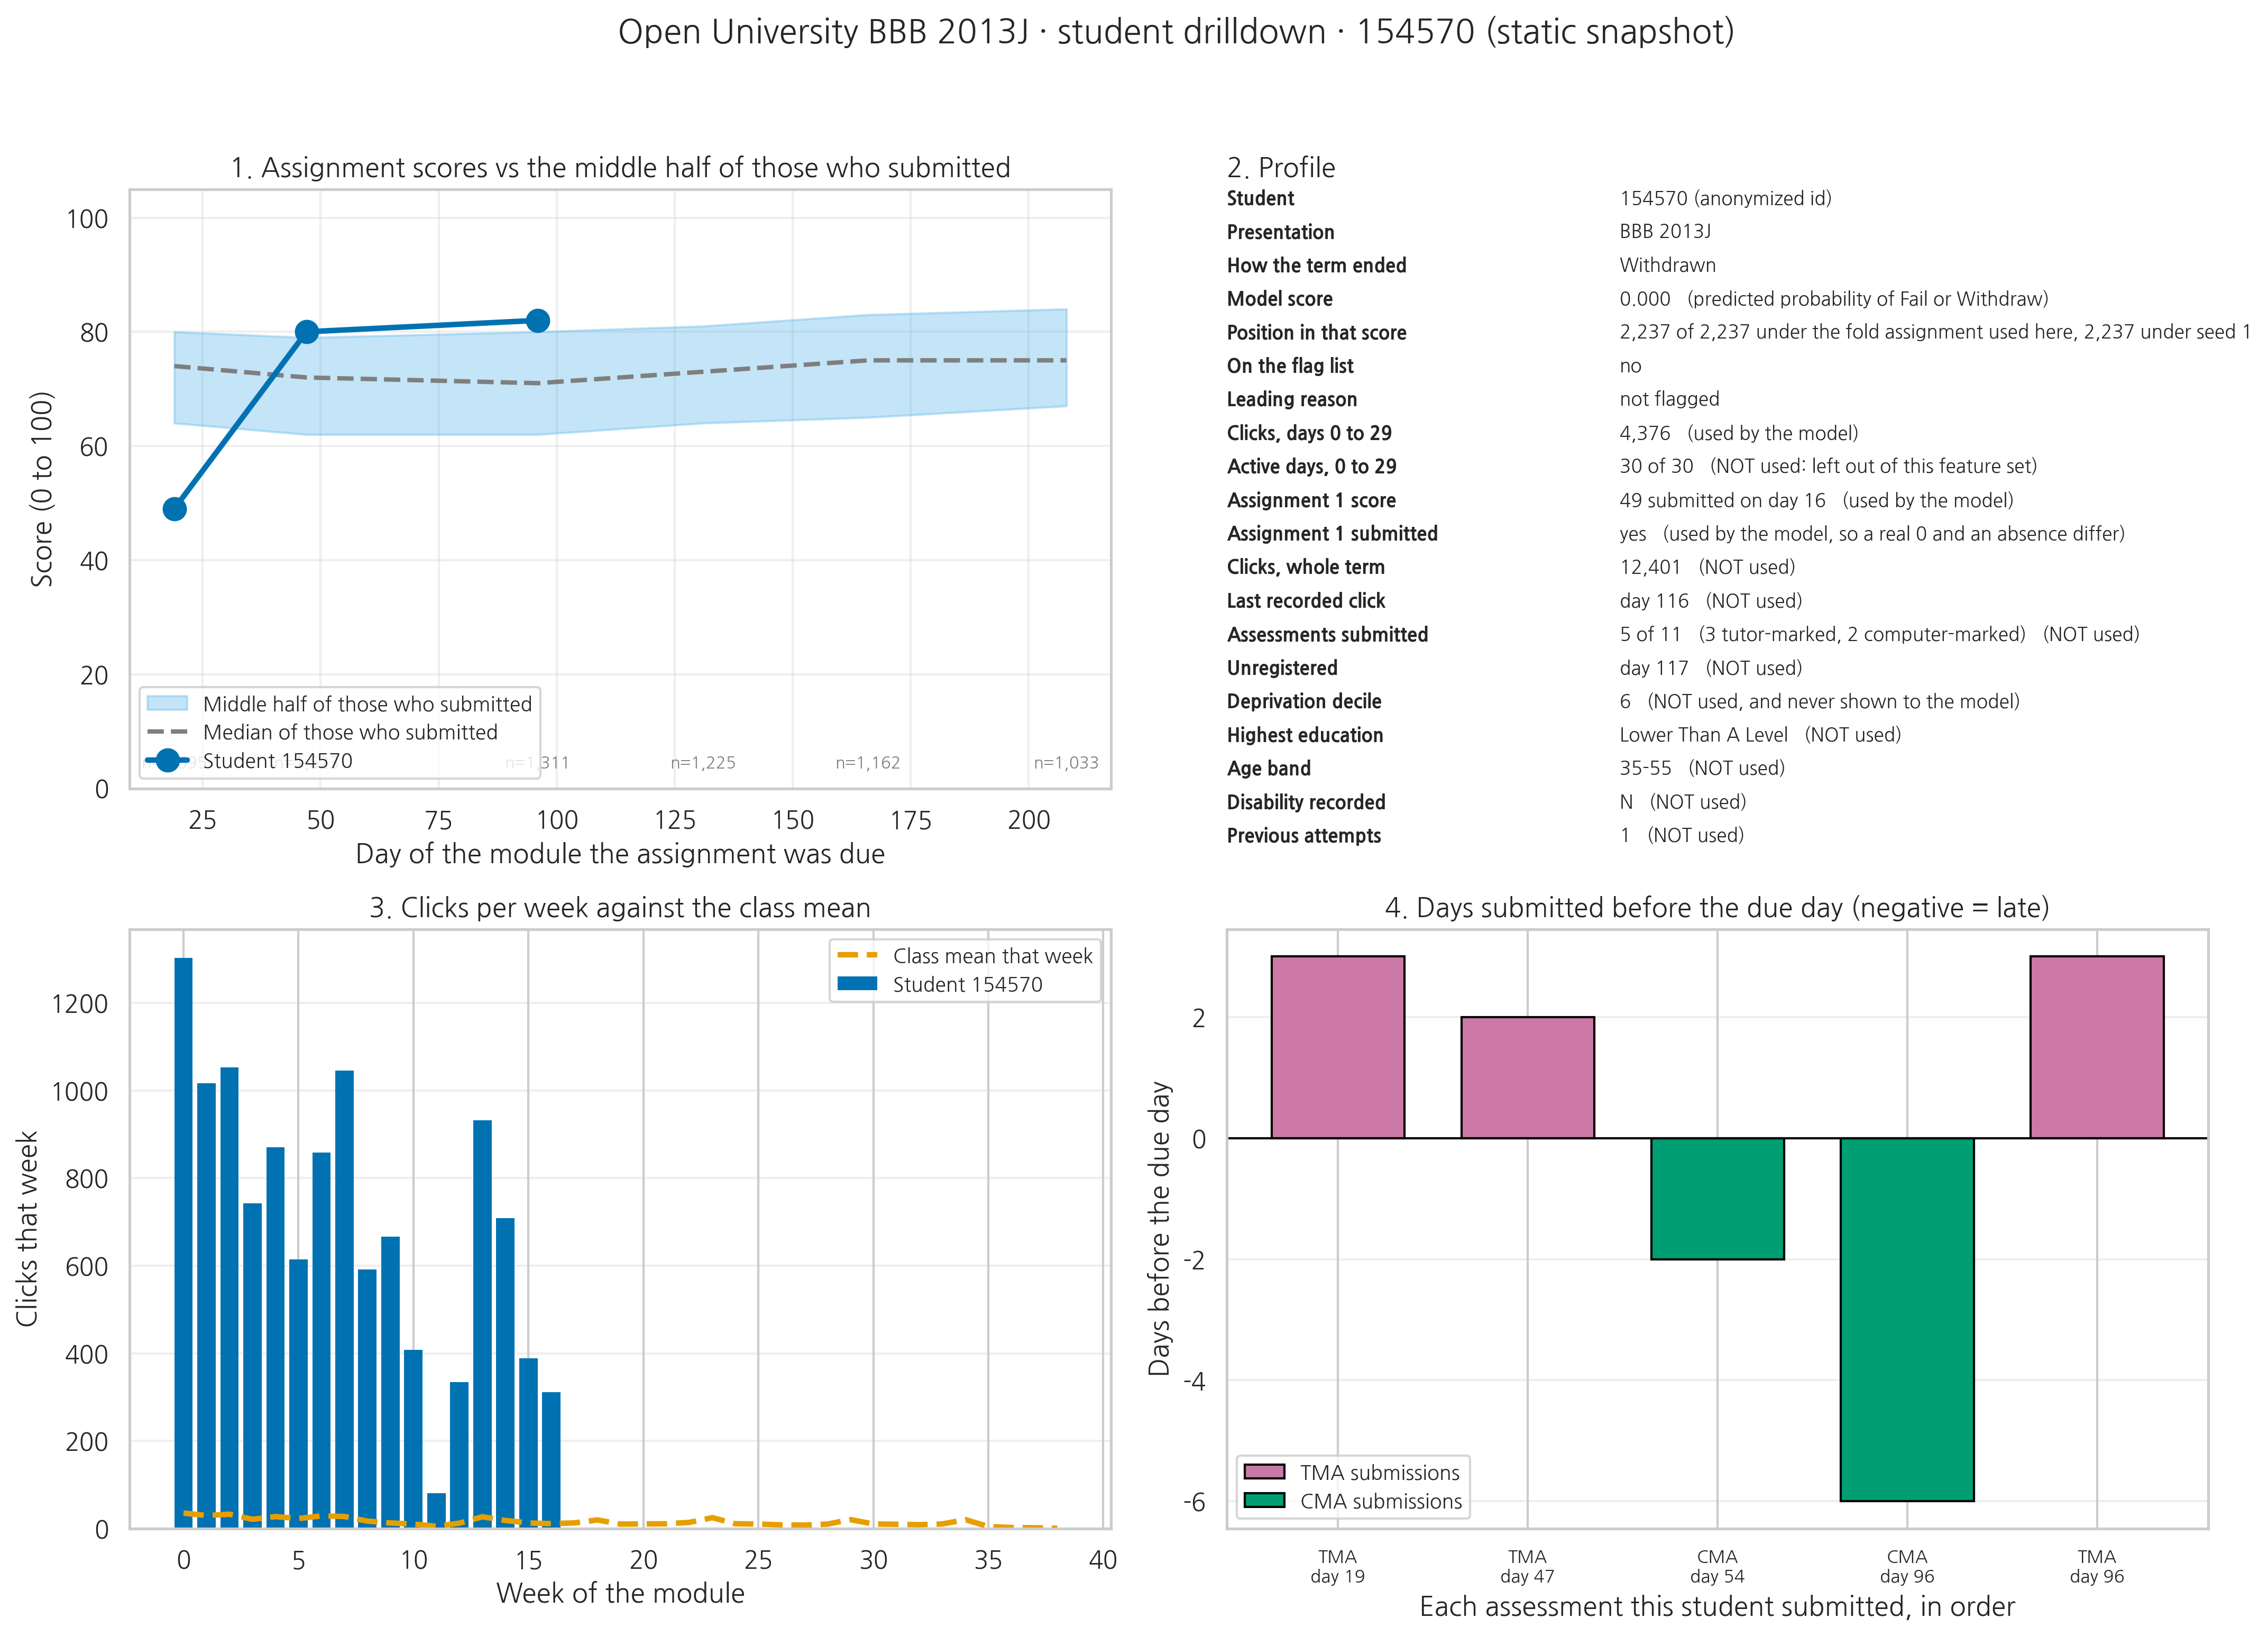

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10.5))

# --- 1. assignment trajectory -----------------------------------------------
ax = axes[0, 0]
ax.fill_between(band.index, band["q25"], band["q75"], color=SKY, alpha=0.35,
                label="Middle half of those who submitted")
ax.plot(band.index, band["q50"], color=GREY, linestyle="--", linewidth=2,
        label="Median of those who submitted")
for _d, _n in zip(band.index, band["n"]):
    ax.annotate(f"n={int(_n):,}", (_d, 3), ha="center", va="bottom", fontsize=7.5,
                color=GREY)
ax.plot(their_tma["date"], their_tma["score"], color=BLUE, marker="o", markersize=10,
        linewidth=2.5, label=f"Student {STUDENT_ID}")
ax.set_ylim(0, 105)
ax.set_title("1. Assignment scores vs the middle half of those who submitted", fontsize=12)
ax.set_xlabel("Day of the module the assignment was due")
ax.set_ylabel("Score (0 to 100)")
ax.legend(fontsize=9, loc="lower left"); ax.grid(alpha=0.3); ax.set_axisbelow(True)

# --- 2. profile as text ------------------------------------------------------
ax = axes[0, 1]
ax.axis("off")
ax.set_title("2. Profile", fontsize=12, loc="left")
for j, (k, v) in enumerate(profile):
    ax.text(0.0, 1.0 - j * 0.056, k, fontsize=8.5, fontweight="bold", va="top",
            transform=ax.transAxes)
    ax.text(0.40, 1.0 - j * 0.056, v, fontsize=8.5, va="top", transform=ax.transAxes)

# --- 3. weekly clicks --------------------------------------------------------
ax = axes[1, 0]
ax.bar(weeks_axis, their_week.values, color=BLUE, edgecolor="none",
       label=f"Student {STUDENT_ID}")
ax.plot(weeks_axis, class_week_mean.values, color=ORANGE, linestyle="--", linewidth=2.5,
        label="Class mean that week")
ax.set_title("3. Clicks per week against the class mean", fontsize=12)
ax.set_xlabel("Week of the module")
ax.set_ylabel("Clicks that week")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)

# --- 4. submission timing ----------------------------------------------------
ax = axes[1, 1]
for atype, color in [("TMA", PURPLE), ("CMA", GREEN)]:
    g = theirs[theirs["assessment_type"] == atype]
    ax.bar(g["slot"], g["days_early"], width=0.7, color=color, edgecolor="black",
           label=f"{atype} submissions")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(theirs["slot"].tolist())
ax.set_xticklabels(theirs["slot_label_plain"].tolist(), fontsize=8)
ax.set_title("4. Days submitted before the due day (negative = late)", fontsize=12)
ax.set_xlabel("Each assessment this student submitted, in order")
ax.set_ylabel("Days before the due day")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)

fig.suptitle(f"Open University BBB {FOCAL_TERM} · student drilldown · {STUDENT_ID} "
             "(static snapshot)", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Let's discuss**, about the student you drilled into.

**1.** What is the first sentence of the email a teacher sends after looking at the early warning panel alone? And the first sentence after looking at this drilldown? If the two are different, the panel is changing what the teacher writes.

**2.** For the default student, chart 3 shows recorded clicks in every week through week 16, the last recorded click on day 116, and no recorded clicks after it. The early warning model looked only at days 0 to 29. What would the model have needed in order to see this student leave, and what would it have cost to give it that?

**3.** The profile card lists what the model never saw, including the area deprivation decile and whether a disability is recorded. Some dashboards hide those fields; some show them. Which would you ship, and on what grounds?

**4.** Which single chart would you hand to the student themselves, unchanged? Which would you not show them? Your answer is the starting point for the optional section at the end.


## The vocabulary the critique and the memo use

Part E asks you to critique your own panels and Part F asks you to argue for one change to them. Both are graded on whether you use this week's frameworks by name. Here is what to use.

### The design space (van Leeuwen, Teasley, and Wise, 2022)

Seven coordinates. Please place each of your three panels on all seven.

| Coordinate | The choice |
|---|---|
| **Audience** | Teacher, student, both, or a third party such as an advisor, an administrator, or a parent. This is the primary axis, and it carries a second question: who else can see the display. |
| **Purpose** | Awareness, reflection, prediction, feedback, accountability. |
| **Reference frame** | The learner's own past, a stated goal, the class average, an expert model. "there is the question of what reference point the data should be compared to (e.g. a pre-determined standard or relative values for peers)" (p. 131). |
| **Grain size** | Whole class, group, individual, single action. |
| **Timing** | Live during class, weekly, or at the end of term when the learning is over. |
| **Agency** | Who is able to act on what is shown, and under what constraints. In cognitive tutors "the computer is in control, whereas dashboards offer information to students, who decide on any possible follow-up actions" (p. 133). |
| **Where the data sits** | Extracted analytics show traces "in an interface separate from the learning environment that generated them"; embedded analytics show them "directly in the learning environment that generated them" (p. 132). |

Where do all three of your panels sit identically, and is that a design choice or an accident?

### Mirroring, alerting, advising

- **Mirroring** reflects activity back without judgment. Here is what your group did last session.
- **Alerting** flags departure from an expected state. Five students have not opened the assignment.
- **Advising** recommends an action. Consider a check-in with Group 7.

Each step moves interpretive work from the recipient into the system, and moves responsibility with it. Systems that advise on specific teacher behaviors are "rare and hard to design since the impact of teachers' actions can be very context-specific" (p. 132). Please label each of your panels with one of the three words, and notice which label was hardest to assign.

### Where the cycle breaks (Wise and Jung, 2019)

An instructor's use of analytics runs from a question, through reading the data, to explaining a pattern, to responding, to checking impact. Five places it stops:

- **No intention.** A dashboard opened out of curiosity produces browsing rather than decisions. Instructors read against a pedagogical purpose they already had.
- **No reference point.** "I'm really not sure [what this means] because I don't know what normal is" (IN4, p. 61). Zero was one of the few absolute reference points available, so instructors compared across students instead, and "In a class with low overall engagement, even students doing more than average may not be doing enough" (p. 61).
- **No context.** A flagged student the instructor does not know is a name rather than a case.
- **No repertoire.** A correct diagnosis with no available response leaves the instructor unable to act on it.
- **No feedback loop.** "In contrast to the first three phases of analytics use, no themes emerged in relation to the final phase of checking impact" (p. 63).

### Three ways a dashboard misleads honestly

- **Proxy drift.** The indicator, clicks or minutes or posts, becomes the construct, engagement or effort or learning, in the reader's mind. A well-designed panel accelerates that substitution rather than resisting it.
- **Missing denominator.** A flag without a base rate invites over-reaction. A list of 150 names drawn from 2,237 enrollments reads differently once you know that 103 of those names had already unregistered.
- **Actionability mismatch.** The panel invites a response the teacher cannot make at scale, so the panel trains the teacher to ignore it.

None of these requires bad data, a bad model, or bad intent. That is what makes them design problems rather than ethics problems, until they become ethics problems.

### Heuristics you can defend in a memo

- For every indicator, finish this sentence: if this is high or low, a teacher would ______. If you cannot finish it, cut the indicator.
- Put the reference frame on the chart itself rather than in a caption nobody reads.
- Design for a thirty-second read, because thirty seconds is the actual budget.
- Show uncertainty where it exists. A probability rendered as red, amber, or green loses the honesty and keeps the authority.
- Write a line beside every panel saying what it does not tell you.

### The readings, in one line each

| Reading | The claim to hold against what you built |
|---|---|
| **van Leeuwen, Teasley, and Wise (2022)** | Teacher-facing and student-facing analytics are not the same tool with different logins. They answer to different decisions, carry different risks, and a display that supports one can harm the other. Their unit is the design space. |
| **Wise and Jung (2019)** | What an instructor does with a dashboard depends more on their pedagogical situation, their read of the moment, and the moves they already had available than on what the numbers say. The data does not produce the decision; it enters an interpretation already under way. Their unit is the instructor's cycle. |
| **Jung and Wise (2025)** | Students opened the messages at high rates and clicked the links inside them rarely. What they did instead was carry the suggestion into a later visit. Their unit is the student's routine. |


## Part E. Critique

You have three panels. This is the half of the assignment the grade rests on.

van Leeuwen, Teasley, and Wise (2022) make the distinction this notebook uses: teacher-facing and student-facing analytics are not the same tool with different logins. They answer to different decisions, they carry different risks, and a display that supports one can harm the other. Wise and Jung (2019) go further: what an instructor does with a dashboard depends on their pedagogical situation, their reading of the moment, and the responses already in their repertoire, at least as much as on what the numbers say.

So the question is not "is this dashboard accurate." It is: **what would a teacher do differently on Monday because of each panel, and where would that action go wrong?**

**Run the cell below.** It computes six things worth having in view before you write. None of them is visible on the dashboard itself, and the last one asks not whether the model is accurate or fair, but whether it is doing anything a single column was not already doing.


In [14]:
print("=" * 90)
print("  SIX THINGS THE DASHBOARD DOES NOT SHOW THE TEACHER")
print("=" * 90)

n_not_passed = int(y_true.sum())

# --- 1. coverage -------------------------------------------------------------
print(f"\n1. COVERAGE. The panel shows {CASELOAD} names out of {len(term):,} enrollments.")
print(f"   Enrollments ending in Fail or Withdraw ............. {n_not_passed:,}")
print(f"   Of the {CASELOAD} flagged, ended in Fail or Withdraw ....... {tp}")
print(f"   Of the {CASELOAD} flagged, went on to complete ............. {fp}")
print(f"   Ended in Fail or Withdraw and never appear ......... {missed:,}")
print(f"   A team that works the list names {tp / n_not_passed:.1%} of the enrollments that")
print("   ended badly, and hears nothing at all about the rest. Whether the people")
print("   behind those names wanted a phone call is a question no column here answers.")

# --- 2. people the roster still lists, who had already left ------------------
n_already_left = int(already_left.sum())
n_flag_already_left = int(flags_audited[already_left].sum())
print(f"\n2. THE ROSTER. {n_already_left} enrollments unregistered on or before day 0,")
print(f"   and {int((term.loc[already_left, 'clicks_total'] == 0).sum())} of those have no click recorded anywhere.")
print(f"   How many of the {CASELOAD} flag slots they occupy ......... {n_flag_already_left}")
print(f"   That is {n_flag_already_left / CASELOAD:.0%} of a week of outreach aimed at enrollments with an")
print("   unregistration date on or before day 0. Nothing on the panel says so,")
print("   because the panel does not read the unregistration date the registration")
print("   file records.")
# what one roster rule changes, at the same caseload
live = term[term["left_before_day_1"] == 0].reset_index(drop=True)
y_live = live["did_not_pass"].to_numpy()
s_live = cross_val_predict(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    live[AUDITED_FEATURES].to_numpy(dtype=float), y_live,
    cv=StratifiedKFold(5, shuffle=True, random_state=8100), method="predict_proba")[:, 1]
f_live = flag_top_k(s_live, CASELOAD)
tp_live = int(((f_live == 1) & (y_live == 1)).sum())
correct_and_reachable_before = int(((flags_audited == 1) & (y_true == 1) & (~already_left)).sum())
# "Reachable" is a claim about day 30, the earliest this list can exist, not about
# day 0. 75 more enrollments in this term left between day 1 and day 30, and the
# roster rule below does not catch them.
live_still_at_30 = (live["date_unregistration"].isna() |
                    (live["date_unregistration"] > EARLY_WINDOW)).to_numpy()
correct_still_at_30_before = int(((flags_audited == 1) & (y_true == 1) & still_at_30).sum())
correct_still_at_30_after = int(((f_live == 1) & (y_live == 1) & live_still_at_30).sum())
print(f"\n   Same model, same caseload of {CASELOAD}, but only enrollments still")
print(f"   registered on day 1 are eligible:")
print(f"       ended in Fail or Withdraw, still registered ..... {int(y_live.sum()):,}")
print(f"       correct names on the list ...................... {tp_live}")
print(f"       'reach' .......................................  {tp_live / y_live.sum():.1%}"
      f"   (was {tp / n_not_passed:.1%})")
print()
print("   That reach comparison does not stand on its own. The denominator changed:")
print(f"   dropping the {n_already_left} already-gone enrollments removes "
      f"{n_not_passed - int(y_live.sum()):,} from the")
print("   count of enrollments that ended badly, so the percentage rises partly by")
print("   arithmetic. Here is the comparison that is not an artifact, because both")
print("   sides count the same thing: correct names belonging to somebody who was")
print("   still registered on day 1.")
print(f"       before the roster rule ......................... {correct_and_reachable_before}")
print(f"       after the roster rule .......................... {tp_live}")
print("   The model specification did not change; only the eligible population did.")
print()
print(f"   Now tighten the word 'reachable'. This list cannot be drawn before day "
      f"{EARLY_WINDOW},")
print("   because it reads the first 30 days and an assignment due on day 19, and")
print(f"   {int((~still_at_30).sum())} enrollments had unregistered by then, not "
      f"{n_already_left}. Counting only names")
print("   belonging to somebody still registered on the day the list exists:")
print(f"       before the roster rule ......................... {correct_still_at_30_before}")
print(f"       after the roster rule .......................... {correct_still_at_30_after}")
print("   Same direction, smaller on both sides, and the defensible version. A roster")
print("   rule written for day 1 leaves the day-30 leavers on the list, and the")
print("   word 'reachable' claimed more than the computation showed.")

# --- 3. stability ------------------------------------------------------------
appearances = pd.Series(0, index=term["id_student"])
for seed in [1, 2, 3, 4, 5]:
    picked = flag_top_k(risk_scores(AUDITED_FEATURES, seed=seed), CASELOAD)
    appearances[term.loc[picked == 1, "id_student"]] += 1
ever = appearances[appearances > 0]
always = int((ever == 5).sum())
print(f"\n3. STABILITY. The same model, the same data, five different random splits")
print("   for the cross validation. Nothing about any person changed.")
print(f"   Enrollments on all 5 lists ......................... {always}")
print(f"   On some lists but not others ....................... {len(ever) - always}")
print(f"   Distinct enrollments appearing at least once ....... {len(ever)} for {CASELOAD} slots")
print(f"   The cause is in the printout above: {int(no_evidence.sum())} enrollments have no")
print("   recorded clicks and no assignment 1, so the model cannot rank them and the")
print("   sort order decides who gets a phone call. The screen shows a ranked list")
print("   anyway, which is the panel asserting a precision it does not have.")

# --- 4. who the list is made of, in the terms a teacher would use ------------
share_list = list_share_deprived(flags_audited)
share_class = float(deprived.mean())
d1 = float(term.loc[term["imd_decile"] == 1, "did_not_pass"].mean())
d10 = float(term.loc[term["imd_decile"] == 10, "did_not_pass"].mean())
fp_dep, n_dep = false_positive_count(flags_audited, deprived)
fp_rest, n_rest = false_positive_count(flags_audited, rest)
fp_dep_ret, _ = false_positive_count(flags_retired, deprived)
fp_rest_ret, _ = false_positive_count(flags_retired, rest)
print(f"\n4. WHO THE LIST IS MADE OF, AND A FAIRNESS NUMBER BUILT FROM THREE EVENTS.")
print(f"   The shipped model's false positive rate gap is "
      f"{false_positive_rate(flags_audited, deprived) - false_positive_rate(flags_audited, rest):+.4f}"
      f", the retired one's is "
      f"{false_positive_rate(flags_retired, deprived) - false_positive_rate(flags_retired, rest):+.4f}.")
print(f"   Now the denominators. Shipped model: {fp_dep} false positives among "
      f"{n_dep} completing")
print(f"   enrollments in the most deprived 30%, and {fp_rest} among {n_rest} in the rest.")
print(f"   Retired model: {fp_dep_ret} and {fp_rest_ret}.")
print("   This is not the shipped model being fairer than the retired one.")
print("   It is a top-k caseload rule: with")
print(f"   {CASELOAD} slots and {n_not_passed:,} enrollments that ended badly, essentially nobody")
print("   who completed gets flagged by ANY model, so the false positive rate is")
print("   pinned near zero and cannot distinguish between designs. The rate is")
print("   computable under a probability threshold instead: a cutoff of 0.50 flags")
print("   2,381 of the 4,529 enrollments, both presentations together, which puts the")
print("   false positive counts in the hundreds. A caseload rule takes that away.")
print()
print("   What an audit of this module over a 60-day window established, and what")
print("   still holds here:")
print("     - dropping active_days lowered the overall false positive rate (0.287 to")
print("       0.074; 638 false positives to 164)")
print("     - no error-rate GRADIENT across the deciles was ever detectable, before")
print("       or after, once ten comparisons were accounted for")
print("     - the gradient in WHO GETS FLAGGED did not flatten, and may have steepened")
print()
rr4, rr4_lo, rr4_hi, a4, na4, b4, nb4 = flag_rate_ratio(flags_audited, deprived, rest)
print(f"   The list here skews the same way. Most deprived 30% of the class .... {share_class:.1%}"
      f"  ({int(deprived.sum()):,} of {len(term):,})")
print(f"                                    Most deprived 30% of the LIST .... {share_list:.1%}"
      f"  ({int((term.loc[flags_audited == 1, 'imd_group'] == 'Most deprived 30%').sum())} "
      f"of {CASELOAD})")
print(f"                                    flag rate ratio ................. "
      f"{rr4:.2f} to 1   95% [{rr4_lo:.2f}, {rr4_hi:.2f}]")
print(f"                                    built from ...................... "
      f"{a4} flags in {na4:,} against {b4} in {nb4:,}")
print("   That is the one fairness quantity on this page with enough events under it")
print("   to carry an interval, and the interval clears 1. Report this, not the gap.")
print(f"   The skew follows the recorded outcome gradient: enrollments in decile 1")
print(f"   ended in Fail or Withdraw at {d1:.1%} and in decile 10 at {d10:.1%}. The file does")
print("   not record why that gradient exists.")
print("   An accurate list reproduces it, and a fairness metric computed")
print("   only on the enrollments that completed will report that nothing is wrong.")

# --- 5. what a 30-day window cannot see -------------------------------------
late_leavers = ((term["final_result"] == "Withdrawn") &
                (term["date_unregistration"] > 100)).to_numpy()
n_late = int(late_leavers.sum())
n_late_flagged = int(flags_audited[late_leavers].sum())
missed_mask = (flags_audited == 0) & (y_true == 1)
n_missed_submitted = int(term.loc[missed_mask, "tma1_submitted"].sum())
print(f"\n5. THE WINDOW. The model sees days 0 to {EARLY_WINDOW - 1} and assignment 1, and")
print(f"   then never looks again. {n_late} enrollments were withdrawn after day 100.")
print(f"   How many of them the panel had flagged ............. {n_late_flagged}")
print(f"   Of the {missed:,} enrollments ending in Fail or Withdraw that the list")
print(f"   never names, how many submitted assignment 1 ....... {n_missed_submitted:,}")
print("   An early warning system is a claim that the early part of a course")
print("   predicts the rest of it. For these enrollments the first 30 days did not")
print("   predict the recorded outcome.")

# --- 6. what the model added over one indicator -----------------------------
rule6 = (term["tma1_submitted"] == 0).to_numpy()
n6, bad6 = int(rule6.sum()), int(y_true[rule6].sum())
big = flag_top_k(scores_audited, n6)
print(f"\n6. THE MODEL, AGAINST ONE INDICATOR. Every one of the {CASELOAD} names has the")
print("   same leading reason: no assignment 1 recorded as submitted. So ask what")
print("   the regression added to that one column.")
print(f"   Enrollments with no assignment 1 recorded ......... {n6}")
print(f"   Of those, ended in Fail or Withdraw ............... {bad6}   ({bad6 / n6:.1%})")
print(f"   Precision of the model's {CASELOAD} names ................ {tp / CASELOAD:.1%}")
print(f"   Precision of ANY {CASELOAD} drawn from that group ........ {bad6 / n6:.1%}")
print(f"   Precision of the model at a caseload of {n6} ......... "
      f"{int(((big == 1) & (y_true == 1)).sum()) / n6:.1%}")
_lo6, _hi6 = wilson(tp, CASELOAD)
print(f"   95% interval on the model's {CASELOAD} names ............ "
      f"[{_lo6:.1%}, {_hi6:.1%}]")
print(f"   The rule's {bad6 / n6:.1%} sits inside that interval, so at this caseload the")
print("   two cannot be told apart on precision.")
print(f"   The model's ranking inside that group does not raise precision at this")
print(f"   caseload: {tp / CASELOAD:.1%} against {bad6 / n6:.1%}. What the")
print("   caseload of 150 actually does is choose 150 of those enrollments, and")
print("   Part E item 3 already showed the choosing is a reshuffle. Before anyone")
print("   asks whether this model is fair or accurate, ask what it is adding.")
print("\n" + "=" * 90)

  SIX THINGS THE DASHBOARD DOES NOT SHOW THE TEACHER

1. COVERAGE. The panel shows 150 names out of 2,237 enrollments.
   Enrollments ending in Fail or Withdraw ............. 1,165
   Of the 150 flagged, ended in Fail or Withdraw ....... 146
   Of the 150 flagged, went on to complete ............. 4
   Ended in Fail or Withdraw and never appear ......... 1,019
   A team that works the list names 12.5% of the enrollments that
   ended badly, and hears nothing at all about the rest. Whether the people
   behind those names wanted a phone call is a question no column here answers.

2. THE ROSTER. 336 enrollments unregistered on or before day 0,
   and 275 of those have no click recorded anywhere.
   How many of the 150 flag slots they occupy ......... 103
   That is 69% of a week of outreach aimed at enrollments with an
   unregistration date on or before day 0. Nothing on the panel says so,
   because the panel does not read the unregistration date the registration
   file records.

   S

### Your turn 4: the critique table

Please fill this in. It is the analytic core of Mini Project 1, and it is what the memo argues from. Double click this cell to edit it, replace the bracketed text, and keep each entry to one or two sentences.

Two constraints. In the action column, please name something a teacher or module team could do on a Monday: send a specific message, change a specific activity, reorganize a specific ten minutes of a tutorial. "Monitor the student" is not an action. In the misleads column, please name a specific person or group who gets the wrong end of it, using evidence from the printouts above.

| Panel | What a teacher would do | What could mislead them, and who pays |
|---|---|---|
| **B. Class overview** | [your answer] | [your answer] |
| **C. Early warning** | [your answer] | [your answer] |
| **D. Drilldown** | [your answer] | [your answer] |

Then three short answers below the table, a sentence or two each.

**a. Wise and Jung (2019) describe instructional decisions as situated:** the same number leads to different actions depending on where the teacher is in their course. Please pick one panel and describe two teachers who would read it identically and act on it in opposite ways. What should the panel display next to the number?

*[your answer]*

**b. van Leeuwen, Teasley, and Wise (2022) separate teacher-facing from student-facing analytics.** Please take one element of your dashboard and say what would have to change before a student could see it, and what harm the unchanged version would do.

*[your answer]*

**c. 422 enrollments are indistinguishable to the model, and the sort order decides which of them is contacted.** Please design one concrete interface change that communicates that to a teacher without making the panel unusable, and say what your change costs.

*[your answer]*


## Part F. The design memo (300 words)

**This is the primary component used for grading Mini Project 1.** Double click this cell and write your memo in place of the prompts below. Aim for 300 words, give or take about thirty. Prose rather than bullets.

The memo has one job: **argue for one specific change to this dashboard, and respond to the strongest objection you can think of.**

**One thing the memo needs to include.** Somewhere in it, please say what the module team should do about the finding in Part E, item 4: enrollments from the most deprived third of areas are flagged at 8.5 percent against 5.6 percent for the rest, a ratio of 1.52 with a 95 percent interval of [1.11, 2.07], built from 71 flags in 833 enrollments against 78 in 1,388. Please quote it with that interval and those counts, and keep in view that the index bands the area somebody lived in rather than the person.

Two moves are not available here. "The false positive rate gap is closed" will not carry the point, because that number is built from four false positives in total. And "fix the model" will not either, because the gradient in who gets flagged is the module's own recorded outcome gradient appearing in an accurate list.

If your proposed change is to the model, Part E item 6 is the obstacle to clear first: at this caseload the model's names are right 97.3 percent of the time and the rule "no assignment 1 recorded as submitted" is right 96.5 percent of the time, on 592 enrollments, and the interval on the model's 146 correct out of 150 contains the rule's rate. Please argue against that rule rather than against chance.

A memo in the top band does all of the following.

1. **Names the decision.** Which teacher or team, at what moment in their week, facing what choice.
2. **Cites its own evidence.** Numbers from this notebook rather than adjectives, each with the denominator it rests on. If a number is built from single-digit counts, please say so.
3. **Proposes one change, specifically.** Not "add more context." What appears on the screen, where, in what form, and what it displaces.
4. **Names who is protected and what it costs.** Every design decision here trades somebody's error against somebody else's.

---

### Design memo

*[Replace this whole block with your memo.]*

**The decision this dashboard enters.** [Which teacher or team, which moment, which choice they are facing.]

**What the current design does to that decision.** [Cite two specific numbers from this notebook.]

**The change I would make.** [One change. Be concrete about what appears on screen and what it replaces.]

**The deprivation skew, and what should happen about it.** [Required. Not a model fix. Who acts, and on what.]

**Who this protects, what it costs, and the best argument against it.** [Name the group. Name the trade. Then state the objection in its strongest form.]

*Word count: [fill in]*


## Part G. Rebuild it with an AI tool

The critique in Part E and the memo in Part F say what this dashboard should have been. This is where you build that version, and you do not write the code.

Two steps, and neither one asks you to describe the data from memory.

**Step 1. Have the prompt written for you.** Run the cell below. It prints a summary of what this notebook established: the six decisions from Part A, the numbers behind each panel, and the two questions you wrote in Your turn 1. Copy the whole block, paste it into any AI assistant, and ask it to turn the block into a build prompt for a single-page teacher-facing dashboard. Ask it for a prompt, not for code.

**Step 2. Build it.** Paste that prompt into Claude and let it build the page. Claude returns something you can click, so you can see whether the design survives contact with the numbers. Read what it made, then change one thing in the prompt and run it again.

**Three things to check against the printout.** The tool has none of Part A's decision log except what your prompt carries.

1. The denominator under each panel, and whether the screen says anywhere that some rows are missing.
2. Whether a title names a recorded event or a kind of person. "Students who dropped out" and "enrollments with an unregistration date" are different claims about the same column.
3. Whether anything on the screen shows that 422 enrollments are indistinguishable to the model.

**What to keep.** Both prompts, the block you pasted, and a screenshot or link to what Claude built. These go in your AI interaction log with everything else. A panel that renders is not yet a panel that is true of these records.


In [15]:
# =========================================================================
# PART G, STEP 1. A summary of this notebook, ready to paste into an AI tool.
# Run this cell, then copy everything between the two rules.
# =========================================================================
_flags_g = flag_top_k(scores_audited, CASELOAD)
_gone_g = int(_flags_g[(term["left_before_day_1"] == 1).to_numpy()].sum())
_reach_g = tp / y_true.sum()

print("-" * 78)
print(f"""CONTEXT FOR A DASHBOARD BUILD

THE DATA. Open University Learning Analytics Dataset (OULAD), module BBB,
presentation {FOCAL_TERM}: {len(term):,} enrollments, one row each. The file holds
clicks per day, assessment submissions, registration and unregistration dates,
banded demographics, and how the registry closed the enrollment. Published
under CC BY 4.0 by Kuzilek, Hlosta and Zdrahal (2017).

THE AUDIENCE. A module team with one week of outreach time.

SIX THINGS ALREADY DECIDED ABOUT THESE FILES (Part A):
 1. imd_band writes nine of its ten categories with a percent sign, one without.
 2. Twenty-nine enrollments have no imd_band at all.
 3. Day numbers can be negative, because content opens before day 0.
 4. 738 of 4,529 enrollments have no clickstream row anywhere.
 5. Over a thousand have no assignment 1 submission, so the score is absent,
    not low.
 6. 336 enrollments unregistered on or before day 0 and are still in the table.

WHAT THE THREE PANELS SHOWED:
 - Recorded completion rises about 2.7 points per area-deprivation decile in
   2013J and 2.2 in 2014J. The index scores an area, not a person.
 - At a caseload of {CASELOAD}, the flag list is right {tp / CASELOAD:.1%} of the time and
   names {_reach_g:.1%} of the enrollments that end in Fail or Withdraw.
 - The rule "no assignment 1 recorded as submitted" is right {bad6 / n6:.1%} of the
   time on {n6} enrollments, with no model at all.
 - 422 enrollments have identical feature values, so the model cannot tell
   them apart, and {_gone_g} of the {CASELOAD} names had already unregistered.
 - Enrollments from the most deprived 30 percent of areas are flagged at 8.5
   percent, 71 of 833, against 5.6 percent, 78 of 1,388.

A QUESTION THESE FILES CAN INFORM:
{_a}

A QUESTION THESE FILES CANNOT TOUCH:
{_b}
""")
print("-" * 78)
print()
print("  Paste everything between the rules into an AI assistant and ask it to")
print("  turn the block into a build prompt for a single-page teacher-facing")
print("  dashboard. Ask it for a prompt, not for code. Then take that prompt")
print("  to Claude and have it build the page.")


------------------------------------------------------------------------------
CONTEXT FOR A DASHBOARD BUILD

THE DATA. Open University Learning Analytics Dataset (OULAD), module BBB,
presentation 2013J: 2,237 enrollments, one row each. The file holds
clicks per day, assessment submissions, registration and unregistration dates,
banded demographics, and how the registry closed the enrollment. Published
under CC BY 4.0 by Kuzilek, Hlosta and Zdrahal (2017).

THE AUDIENCE. A module team with one week of outreach time.

SIX THINGS ALREADY DECIDED ABOUT THESE FILES (Part A):
 1. imd_band writes nine of its ten categories with a percent sign, one without.
 2. Twenty-nine enrollments have no imd_band at all.
 3. Day numbers can be negative, because content opens before day 0.
 4. 738 of 4,529 enrollments have no clickstream row anywhere.
 5. Over a thousand have no assignment 1 submission, so the score is absent,
    not low.
 6. 336 enrollments unregistered on or before day 0 and are still 

## Going further (optional): redesigning one panel as student facing

Everything from here to the end of the notebook is optional. Please feel free to stop before it.

van Leeuwen, Teasley, and Wise (2022) make the case that a student-facing display is a different instrument, not the same one with a different login. Jung and Wise (2025) study the student side directly: whether students access analytics they receive, whether access turns into action, and what routines form around it. They separate access, action-taking, and learning routines, and in their setting the information arrives as messages rather than as a dashboard somebody has to go and visit. Which stage is your redesign aimed at?

The cell below contains a working student-facing rewrite of the drilldown, so you can see one before building yours. What it removed, and why, is printed underneath it. Some things worth trying: replacing the class band with the student's own earlier scores, replacing the score axis with a list of what to do next, or removing the number entirely and keeping only the trend.

These are distance students whose recorded clicks are intermittent. A student-facing panel somebody sees once, in week 12, on a phone, is the realistic case rather than the edge case.

Then two or three sentences in the reflection below: what changed, what you removed, and what a student can now do that they could not do before.


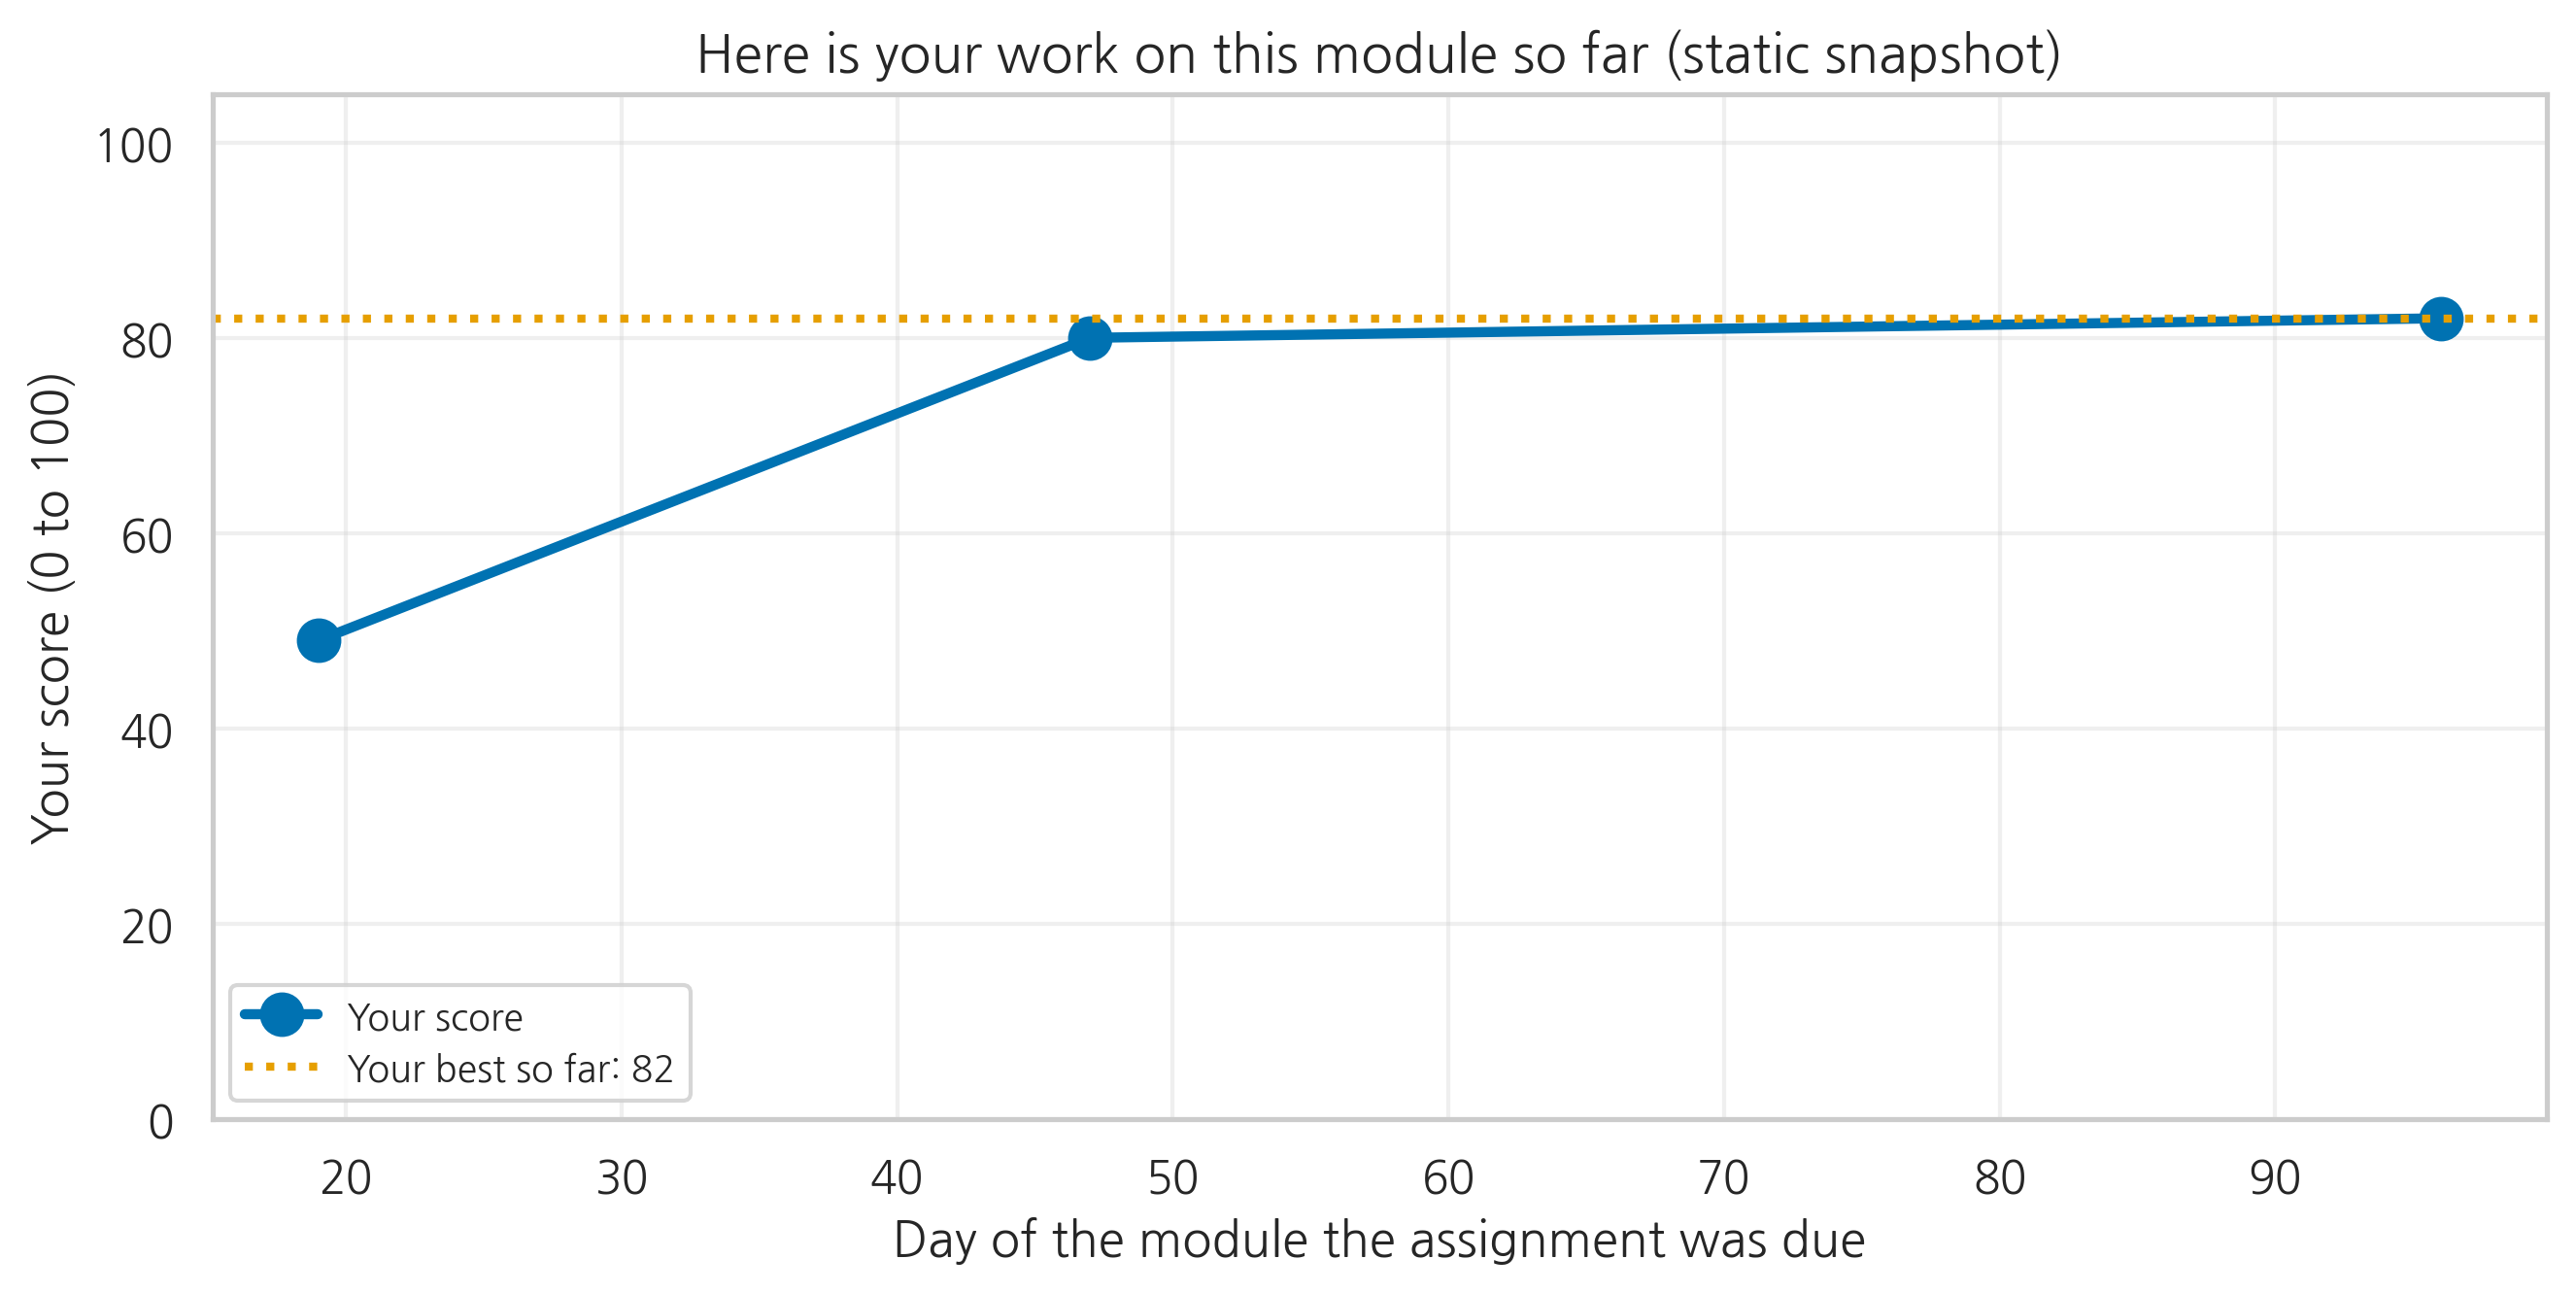

You have submitted 3 tutor-marked assignments. Your first scored 49 and your most recent scored 82. That is up.

WHAT THIS VERSION DELETED, AND WHY
  the risk score ....... a probability about you, computed from 30 days of recorded
                         clicks and one assignment, that you cannot change and
                         cannot question
  the class rank ....... turns a module into a comparison, which a student-facing
                         panel is not for
  the click counts ..... recorded clicks are not a measure of effort, and Part C
                         found the flag list skewed by deprivation decile
  the deprivation band . the model never saw it and the student should never
                         be shown a screen that implies it was consulted

WHAT IT KEPT: the trend, and the student's own best score as the reference point.


In [16]:
# TODO (stretch): this is a working student-facing version of the drilldown.
#      Change it. The comments mark each design decision you could question.

SHOW_CLASS_COMPARISON = False   # try True and decide whether it helped or hurt
STUDENT_FACING_ID = STUDENT_ID


sf = term.set_index("id_student").loc[STUDENT_FACING_ID]
sf_subs = (term_subs[(term_subs["id_student"] == STUDENT_FACING_ID) &
                     (term_subs["assessment_type"] == "TMA")].sort_values("date"))

if len(sf_subs) == 0:
    print(f"Student {STUDENT_FACING_ID} submitted no tutor-marked assignments, so there")
    print("is nothing here to show them. That is itself a design problem.")
    print("a student-facing panel has to have something to say to the students who")
    print("most need one. Pick a different student, or design the empty state.")
else:
    sf_best = float(sf_subs["score"].max())
    sf_first = float(sf_subs["score"].iloc[0])
    sf_last = float(sf_subs["score"].iloc[-1])
    direction = ("up" if sf_last > sf_first + 2 else
                 "steady" if abs(sf_last - sf_first) <= 2 else "down")

    fig = go.Figure()
    if SHOW_CLASS_COMPARISON:
        fig.add_trace(go.Scatter(x=band.index, y=band["q50"], mode="lines",
                                 line=dict(color=GREY, dash="dash"),
                                 name="Median of those who submitted"))
    fig.add_trace(go.Scatter(x=sf_subs["date"], y=sf_subs["score"], mode="lines+markers",
                             line=dict(color=BLUE, width=3), marker=dict(size=12),
                             name="Your score",
                             hovertemplate="day %{x}: %{y:.0f}<extra></extra>"))
    fig.add_hline(y=sf_best, line_dash="dot", line_color=ORANGE,
                  annotation_text=f"your best so far: {sf_best:.0f}",
                  annotation_position="top left")
    fig.update_layout(height=430, width=880, template="simple_white",
                      title=dict(text="Here is your work on this module so far", x=0.5,
                                 font=dict(size=18)),
                      xaxis_title="Day of the module the assignment was due",
                      yaxis_title="Your score (0 to 100)", yaxis=dict(range=[0, 105]))
    fig.show()

    # --- static snapshot of the student-facing panel -------------------------
    fig, ax = plt.subplots(figsize=(9, 4.6))
    if SHOW_CLASS_COMPARISON:
        ax.plot(band.index, band["q50"], color=GREY, linestyle="--", linewidth=2,
                label="Median of those who submitted")
    ax.plot(sf_subs["date"], sf_subs["score"], color=BLUE, marker="o", markersize=10,
            linewidth=2.5, label="Your score")
    ax.axhline(sf_best, color=ORANGE, linestyle=":", linewidth=2,
               label=f"Your best so far: {sf_best:.0f}")
    ax.set_ylim(0, 105)
    ax.set_title("Here is your work on this module so far (static snapshot)", fontsize=13)
    ax.set_xlabel("Day of the module the assignment was due")
    ax.set_ylabel("Your score (0 to 100)")
    ax.legend(fontsize=9, loc="lower left"); ax.grid(alpha=0.3); ax.set_axisbelow(True)
    fig.tight_layout()
    plt.show()

    print(f"You have submitted {len(sf_subs)} tutor-marked assignments. Your first scored "
          f"{sf_first:.0f} and your most recent scored {sf_last:.0f}. That is {direction}.")

print("\nWHAT THIS VERSION DELETED, AND WHY")
print("  the risk score ....... a probability about you, computed from 30 days of recorded")
print("                         clicks and one assignment, that you cannot change and")
print("                         cannot question")
print("  the class rank ....... turns a module into a comparison, which a student-facing")
print("                         panel is not for")
print("  the click counts ..... recorded clicks are not a measure of effort, and Part C")
print("                         found the flag list skewed by deprivation decile")
print("  the deprivation band . the model never saw it and the student should never")
print("                         be shown a screen that implies it was consulted")
print("\nWHAT IT KEPT: the trend, and the student's own best score as the reference point.")

## Reflection

Please bring your answers to the debrief block from 5:30 to 5:50. Our guest this week is Yeonji Jung of Texas A&M University, a co-author of two of this week's readings, which the second and third questions here are built on.

1. **van Leeuwen, Teasley, and Wise (2022)** describe teacher-facing and student-facing analytics as answering different questions for different actors. Having built one and sketched the other, what is the sharpest difference you encountered in the design, as against the one you expected?

2. **Wise and Jung (2019)** argue that instructional decision making is situated. Where in your dashboard did you find yourself designing for a teacher you had imagined? What did you assume about them that a colleague at a distance-teaching university with 2,237 students in one module might not share?

3. **Jung and Wise (2025)** study how students engage with analytics they receive: whether they access it, whether they act, and what routines form. What would you change if you assumed a student who looks once, in week 20, on a phone, the night before an assignment?

4. **Li, Jung, and Wise (2026)** find that pedagogy is pivotal in how instructors use analytics. If that is right, then the highest-leverage change to this dashboard might not be a change to the dashboard. What might it be?

5. These records were analyzed in a notebook and then placed on an interface a teacher would act on. **Kuzilek, Hlosta, and Zdrahal (2017)** published them so that the field could check its own work on data more than one lab can see. Which decision in this notebook would you have made differently if you had known the people in it?


## Submission checklist: Mini Project 1

Due via Canvas by **11:59 PM on Sunday, September 20, 2026**. Wednesday's class launches the project, and the rest may be completed afterwards.

Coding skill is not what is assessed. The design memo in Part F is the primary component used for grading, with the critique table in Part E close behind it.

**The notebook**

- [ ] Runs top to bottom without errors. In Colab: `Runtime > Restart session and run all`.
- [ ] Your turn 1 contains your two questions rather than the defaults.
- [ ] Your turn 2 records a caseload and a roster rule you chose, and you can say why.
- [ ] Your turn 3: Part D was run on at least one student you chose yourself, and the outputs for that student are visible in the saved file.
- [ ] Your turn 4, the critique table in Part E, is filled in for all three panels, plus the three questions underneath it.
- [ ] Please download it: `File > Download > Download .ipynb`, and upload that file to Canvas.

**The design memo**

- [ ] Written in the marked cell in Part F, roughly 300 words.
- [ ] Names a decision, cites at least two numbers from your own outputs, proposes one specific change, and states the strongest objection to it.
- [ ] Says what the module team should do about the deprivation skew, without proposing a model fix.

**Part G, the rebuild**

- [ ] The prompt an AI assistant wrote for you, the prompt you ended up using, and a screenshot or link to what Claude built.
- [ ] Two or three sentences on what the built version got wrong about these records, and what your prompt had to say to fix it.

**The AI interaction log (course policy, required)**

- [ ] If you used an AI assistant at any point, to explain a line of code, to check your reading of a chart, or to help you draft the memo, please save the full exchange. Everything from Part G belongs here too.
- [ ] Paste the full exchanges into a Word file and attach that file to the Canvas **AI Reflection** submission. Please do not paste them into the text box.
- [ ] In the text box on that same page, copy in and answer the four reflection questions from the syllabus: how you used it; whether it helped and how; whether it made your work more challenging in any way; and what lesson about AI from this week you would pass on to a classmate.
- [ ] If you used no AI at all, one line saying so is also documentation.

AI use is permitted in designated activities and is to be documented. Undisclosed use is an Honor Code violation. The reflection matters more than the log: what did you accept from the assistant, and how did you check it?

**Attribution, because the data are real**

- [ ] If you reuse any figure or number from this notebook outside this course, please cite the dataset: Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171. CC BY 4.0.

**One last check before uploading.** Please scroll once from top to bottom and confirm that every static snapshot is present.


## Appendix (optional): worked examples for the Your turn cells

These are worked examples rather than answer keys, and they are here for reference rather than for the session. Your version being different is expected and is usually better, because it comes from a course you have taught or taken.

### Your turn 1: the two questions

```python
QUESTION_THE_FILES_CAN_INFORM = (
    "Among students who submitted assignment 1, which ones scored above the class "
    "median and then never submitted another one?"
)

QUESTION_THE_FILES_CANNOT_TOUCH = (
    "Which of the students who withdrew would have stayed if somebody had "
    "phoned them in week 5, and what would that phone call have had to offer?"
)
```

No panel in this notebook addresses the second question.

### Your turn 2: the caseload and the enrollment table

Three settings worth running:

```python
your_caseload = 50    # a small list
your_caseload = 422   # the size of the group the model cannot tell apart
DROP_ALREADY_GONE = True   # the roster rule, which changes who is on the list rather than how many
```

The roster rule changes the composition of the list; the caseload changes only its length. Part E item 2 is careful about how it says so. The reach figure rises from 12.5 percent to 16.2 percent, but that comparison changes its own denominator, because dropping the 336 already-gone enrollments also drops 336 from the count of enrollments that ended badly. The comparison that is not an artifact counts the same thing on both sides: correct names belonging to somebody still registered on day 1. That goes from **43 to 134**, at the same caseload.

Then tighten it once more, the way Part E item 2 does. This list cannot exist before day 30, and 411 enrollments had unregistered by then rather than 336. Counting only names belonging to somebody still registered on the day the list is drawn, the same rule goes from **29 to 96**. Same direction, smaller on both sides, and it is the version to put in a memo. Setting `DROP_ALREADY_GONE = True` lets you watch it at whatever caseload you choose.

A defensible answer sounds like: "150, because our retention team is two people and 150 substantive calls is a week of their time. But I would spend the first hour of that week on the enrollment table rather than on the model."

### Your turn 3: choosing the student

There is one habit worth avoiding, which is picking whoever is at the top of the risk list and stopping there. The most informative drilldowns in this dataset are the ones where the panel and the person disagree.

The comparison table printed in Part D gives you six. `154570` is the clearest case in the presentation: more recorded clicks in the first 30 days than anyone else, the lowest **model** score of all 2,237, and unregistered on day 117. `182661` is the opposite case: 26 clicks in the entire term, no assignment 1, and passed anyway.

That student's rank is worth handling carefully. The table prints 453 of 2,237, and 182661 is one of the 422 enrollments whose three feature values are identical, so 453 is not a property of this person. It is which cross-validation fold they landed in. Changing the seed can place the same student inside a caseload of 150: under `ALT_SEED = 1` the position is 99. This is the instability Part E item 3 reports, seen for one enrollment.

`583142` has deprivation decile 1 recorded, submitted ten of the eleven assessments this file records, and unregistered on day 241, which is 27 days before the last recorded activity in the presentation. None of the three was flagged; two withdrew and one passed.

### Your turn 4: the critique table

One row, worked at the level the rubric expects:

| Panel | What a teacher would do | What could mislead them, and who pays |
|---|---|---|
| **C. Early warning** | Give the retention team the 150 names on Monday, ask for a call to each within the week, and hold the last twenty slots for students the tutors raise by hand. | Most of the list is not what it appears to be. 103 of the 150 names carry an unregistration date on or before day 0, and 117 by day 30, the earliest day its features exist, so the team spends much of the week calling people who have left, and reports back that early warning does not work. Meanwhile the people who submitted assignment 1, looked ordinary in week 4, and left after day 100 are not on the list at all: 134 enrollments withdrew after day 100 and the panel had flagged 4 of them. Those who pay are the late leavers, who were still registered at day 30 and were never on the list, and the retention team, whose next budget request now has a week of unproductive calls attached to it. |

For question (c), on the 422 indistinguishable enrollments: one workable answer is to stop showing a rank inside that block. Replace positions 1 to 150 with two labeled groups whose names describe the record rather than the person, for example "no activity recorded and no assignment 1" and "activity recorded, assignment 1 missing", show the size of each, and make the first group a single row with a count rather than 140 separate names. The cost is real and worth stating: a teacher who wanted a list to work through now has to make a decision about a group instead of reading names, and some teachers will skip the group.

### Going further: the student-facing redesign

The version in the notebook keeps the trend and the student's own best score, and removes the risk score, the class rank, the click counts, and the deprivation band. A stronger version goes further and attaches an action to the chart: next to each assignment, one specific thing available now, the tutor's office hours, the module forum, the extension request form. The design claim is that a student-facing display without an available action is not feedback.

Setting `SHOW_CLASS_COMPARISON = True` is worth doing once. Then decide whether the added line helps or harms the student it is shown to.

Running it on `182661` is also worth doing. That student submitted one assessment in the whole presentation and it was a computer-marked one, so the panel has no tutor-marked score to show them and the cell prints an empty state instead of a chart. Designing that empty state is part of the exercise.

---

EDIS 8100: Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee
University of Virginia School of Education and Human Development

Data: Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171. Licensed CC BY 4.0.

## Appendix B (optional): the modeling and charting decisions in full

Everything here sits behind a decision the notebook has already made. It is the evidence and the fine print, kept out of the main line so that the main line reads.

### Why `active_days_first30` is left out of the shipped model

One half of the argument is about what the column measures rather than a result. A feature that counts how many separate days contain activity reads the shape of a week, and the shape of a week is set by employment and caring hours that OULAD does not record. No file in this course can test that claim.

The other half is a result, and a modest one. In an audit of the same module over a 60-day window, putting active_days and a resources count back in gave accuracy 0.793 against 0.795 without them, and the share-flagged gradient steepened from about -0.018 to -0.021 per decile step. That steepening could not be shown to exceed noise. So this is a reason not to include the feature rather than a demonstration that it does harm.

The activity-only comparison model here uses `clicks_first30` and `active_days_first30`. The 60-day version of it used clicks, active days, and a resources count.

### Where the shipped feature set comes from

The 60-day version of this feature set was `clicks`, `n_submitted`, `mean_score`, and `no_submission`. With one assignment due inside the first 30 days, `n_submitted` and `no_submission` both reduce to `tma1_submitted`, and `mean_score` reduces to the single score, filled here with 0 where the longer version used the median. `clicks_first30` stays, because volume of work is not the same thing as shape of schedule. Results banked from an earlier presentation are set aside, so an enrollment carrying one counts as no submission this term.

### Why the reason bars and the scores come from different fits

The scores shown on the panel are out of sample, but the feature contributions are read off a model fitted on the whole term, because a per-fold decomposition would give the same student three different explanations. The two differ by at most 0.104 and by 0.006 on average across the 2,237 enrollments, and they are not the same object.

### Three charting decisions in Part D

**Chart 1 plots only the tutor-marked assignments.** The median of the computer-marked ones is full marks in every one of their due-day windows, so including them would flatten every other line on the chart. The Part D cell runs that check and prints it. That omission is a design decision, and the critique table is a good place to say whether you would keep it.

**Chart 3 compares against the class mean rather than the median.** In most weeks of this module the median student recorded zero clicks, so a median line would sit at zero in most weeks. The Part D cell prints exactly how many weeks that is. It is a property of this module's recorded clickstream and it is worth one sentence in the memo.

**Chart 4 gives each submission its own slot** rather than placing it on its due day, because two assessments in this module share a due day and would otherwise be drawn on top of each other.
